In [1]:
import geopandas as gpd
import os
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from datetime import timedelta
import matplotlib as mpl




In [2]:
plt.rcdefaults()                     # reset rcParams
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use('default')             # reset style

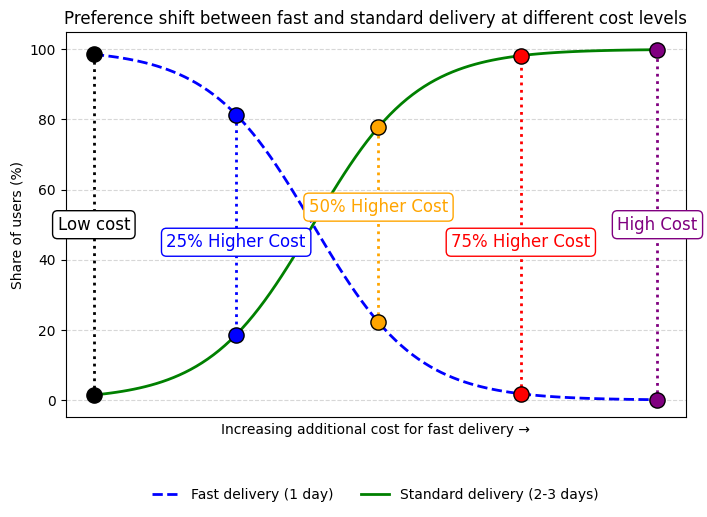

In [3]:
# Plot from EWGT 2025 Abstract

# Define price values (cost increasing)
price = np.linspace(1, 10, 100)  # Price from 1 to 10

# Demand distribution between fast and standard delivery (summing to 100%)
fast_delivery_share = 100 / (1 + np.exp(1.2 * (price - 4.5)))  # Fast delivery preference decreases with price
standard_delivery_share = 100 - fast_delivery_share  # Standard delivery preference increases accordingly

# Define cost-based sample points at 0%, 25%, 50%, 75%, and 100% of the cost range
cost_levels = [0.0, 0.25, 0.50, 0.75, 0.99]  # Avoid index out of range by using 0.99 instead of 1.0
sample_prices = [price[int(len(price) * c)] for c in cost_levels]  # Select corresponding price points

# Compute the corresponding fast and standard delivery shares
fast_shares = [fast_delivery_share[np.argmin(np.abs(price - p))] for p in sample_prices]
standard_shares = [100 - fs for fs in fast_shares]

# Define colors for scenarios
scenario_colors = ["black", "blue", "orange", "red", "purple"]
# Define updated labels based on cost levels rather than share percentages
scenario_labels = ["Low cost", "25% Higher Cost", "50% Higher Cost", "75% Higher Cost", "High Cost"]


label_offsets = [0, -5, 5, -5, 0]  # Adjust vertical position of text labels

# Create the plot again with improved label placement
plt.figure(figsize=(8, 5))
plt.plot(price, fast_delivery_share, label="Fast delivery (1 day)", linewidth=2, linestyle="dashed", color="blue")
plt.plot(price, standard_delivery_share, label="Standard delivery (2-3 days)", linewidth=2, color="green")

# Mark sample scenarios with same-colored points and connect them with vertical dashed lines
for i, (p, f, s) in enumerate(zip(sample_prices, fast_shares, standard_shares)):
    plt.scatter(p, f, color=scenario_colors[i], s=120, edgecolors="black", zorder=3)  # Fast delivery point
    plt.scatter(p, s, color=scenario_colors[i], s=120, edgecolors="black", zorder=3)  # Standard delivery point
    plt.plot([p, p], [f, s], color=scenario_colors[i], linestyle="dotted", linewidth=2, zorder=2)  # Vertical connector
    plt.text(p, (f + s) / 2 + label_offsets[i], scenario_labels[i], fontsize=12, color=scenario_colors[i],
             ha="center", va="center", bbox=dict(facecolor="white", edgecolor=scenario_colors[i], boxstyle="round,pad=0.3"))

# Adjust labels
plt.xlabel("Increasing additional cost for fast delivery →")
plt.ylabel("Share of users (%)")
plt.title("Preference shift between fast and standard delivery at different cost levels")

# Grid and legend below the plot
plt.grid(True, linestyle="dashed", alpha=0.5)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Remove x-axis ticks
plt.xticks([])

plt.show()



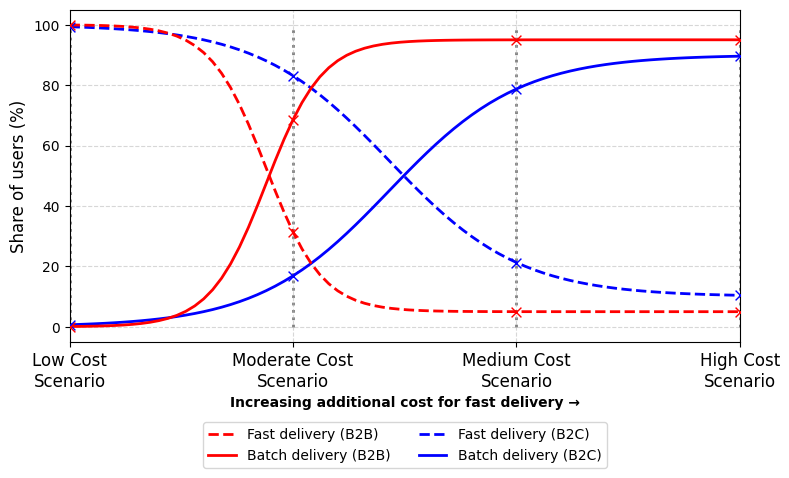

In [8]:
# Jetzt: Vertikale Linien = Szenariofarbe | Kreuze = Linienfarbe (B2B/Neutral/B2C)
import numpy as np
import matplotlib.pyplot as plt

# Preisachse
price = np.linspace(1, 10, 100)

# Preis minimal verschieben für Modellierung
price_shifted = price - 1.25

# B2C-Modell
fast_delivery_b2c = 10 + (90) / (1 + np.exp(1.5 * (price_shifted - 3)))
batch_delivery_b2c = 100 - fast_delivery_b2c

# B2B-Modell
fast_delivery_b2b = 5 + (95) / (1 + np.exp(3.5 * (price_shifted - 1.75)))
batch_delivery_b2b = 100 - fast_delivery_b2b

# Cost levels
cost_levels = [0.0, 0.25, 0.5, 0.75]  # Nur vier Punkte

sample_prices = [price[int(len(price) * c)] for c in cost_levels]

scenario_labels = [
    "Low Cost\nScenario",
    "Moderate Cost\nScenario",
    "Medium Cost\nScenario",
    "High Cost\nScenario"
]

# Scenario colors for vertical lines
scenario_colors = ["black", "blue", "red", "red", "purple"]

# Curve colors for crosses
curve_colors = {
    "fast_b2c": "blue",
    "batch_b2c": "blue",
    "fast_neutral": "green",
    "batch_neutral": "green",
    "fast_b2b": "red",
    "batch_b2b": "red"
}

# Create the plot
plt.figure(figsize=(8,5 ))

# Plot curves
plt.plot(price, fast_delivery_b2c, linestyle="--", color="blue", linewidth=2, label="Fast delivery (B2C)")
plt.plot(price, batch_delivery_b2c, linestyle="-", color="blue", linewidth=2, label="Batch delivery (B2C)")

# plt.plot(price, fast_delivery_neutral, linestyle="--", color="green", linewidth=2, label="Fast delivery (Neutral)")
# plt.plot(price, batch_delivery_neutral, linestyle="-", color="green", linewidth=2, label="Batch delivery (Neutral)")

plt.plot(price, fast_delivery_b2b, linestyle="--", color="red", linewidth=2, label="Fast delivery (B2B)")
plt.plot(price, batch_delivery_b2b, linestyle="-", color="red", linewidth=2, label="Batch delivery (B2B)")

# Add vertical lines and crosses at intersections
for i, p in enumerate(sample_prices):
    scenario_color = scenario_colors[i]
    
    # Vertical line from 0 to 100 in scenario color
    plt.plot([p, p], [0, 100], color="gray", linestyle="dotted", linewidth=2, zorder=1)
    
    # Find closest index
    idx = np.argmin(np.abs(price - p))
    
    # Plot crosses in curve color
    plt.scatter(p, fast_delivery_b2c[idx], color=curve_colors["fast_b2c"], marker='x', s=50, linewidths=1, zorder=3)
    plt.scatter(p, batch_delivery_b2c[idx], color=curve_colors["batch_b2c"], marker='x', s=50, linewidths=1, zorder=3)

    
    plt.scatter(p, fast_delivery_b2b[idx], color=curve_colors["fast_b2b"], marker='x', s=50, linewidths=1, zorder=3)
    plt.scatter(p, batch_delivery_b2b[idx], color=curve_colors["batch_b2b"], marker='x', s=50, linewidths=1, zorder=3)

# Style settings
plt.xlabel("Increasing additional cost for fast delivery →", fontsize=10,fontweight='bold')
plt.xticks(sample_prices, scenario_labels, rotation=00, ha="center", fontsize=12)

plt.ylabel("Share of users (%)", fontsize=12)
# plt.title("Preferences Shift between fast and standard delivery at different cost levels for B2B and B2C parcel delivieries", pad=20)
# plt.xticks([])
plt.ylim(-5, 105)
plt.grid(True, linestyle="dashed", alpha=0.5)

plt.xlim(1, 7.82)  # weil price von 1 bis 10 geht

# Legend (manuell sortiert)
handles, labels = plt.gca().get_legend_handles_labels()
label_handle_dict = dict(zip(labels, handles))

desired_order = [
    "Fast delivery (B2B)",
    "Batch delivery (B2B)",
    "Fast delivery (B2C)",
    "Batch delivery (B2C)"
]

sorted_handles = [label_handle_dict[label] for label in desired_order]
sorted_labels = desired_order

plt.legend(sorted_handles, sorted_labels, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True, fontsize=10)

plt.tight_layout()
# plt.savefig("output/preference_shift_b2b_b2c.pdf", dpi=300, bbox_inches='tight')
plt.show()



In [9]:
def load_all_hagrid_shapefiles(output_dir="output", prefix="hagrid_parcel_demand"):
    """
    Loads all HAGRID Shapefiles from the specified output directory individually.

    Parameters
    ----------
    output_dir : str, default="output"
        Directory where the HAGRID shapefiles are stored.
    prefix : str, default="hagrid_parcel_demand"
        Common filename prefix to identify relevant shapefiles.

    Returns
    -------
    shapefile_dict : dict
        Dictionary where keys are filenames (without extension) and values are GeoDataFrames.
    """
    # Find all matching shapefiles
    shp_files = [f for f in os.listdir(output_dir) if f.endswith(".shp") and f.startswith(prefix)]

    if not shp_files:
        raise FileNotFoundError(f"No shapefiles starting with '{prefix}' found in '{output_dir}'.")

    # Load each shapefile into a dictionary
    shapefile_dict = {}
    for shp_file in sorted(shp_files):  # sorted() to keep chronological order
        path = os.path.join(output_dir, shp_file)
        gdf = gpd.read_file(path)
        key = os.path.splitext(shp_file)[0]  # filename without '.shp'
        shapefile_dict[key] = gdf

    return shapefile_dict

In [10]:
carrier_columns = {
    'Amazon': ('ama', 'amazon_tag', 'amazon_typ'),
    'DHL': ('dhl', 'dhl_tag', 'dhl_type'),
    'DPD': ('dpd', 'dpd_tag', 'dpd_type'),
    'GLS': ('gls', 'gls_tag', 'gls_type'),
    'Hermes': ('her', 'hermes_tag', 'hermes_typ'),
    'UPS': ('ups', 'ups_tag', 'ups_type'),
    'FedEx/TNT': ('fxt', 'fedex_tag', 'fedex_type')
}

# Alle GDFs laden
hagrid_files = load_all_hagrid_shapefiles(output_dir="output")

for filename, gdf in hagrid_files.items():
    total_b2b = gdf[[col for col in gdf.columns if col.endswith('_b2b')]].sum().sum()
    total_b2c = gdf[[col for col in gdf.columns if col.endswith('_b2c')]].sum().sum()
    total_packages = total_b2b + total_b2c

    tag_cols = [tag for _, (_, tag, _) in carrier_columns.items() if tag in gdf.columns]
    type_cols = [typ for _, (_, _, typ) in carrier_columns.items() if typ in gdf.columns]
    total_tag = gdf[tag_cols].sum().sum()
    total_type = gdf[type_cols].sum().sum()
    total_tag_type = total_tag + total_type

    print("=" * 80)
    print(f"{filename}: B2B={total_b2b}, B2C={total_b2c}, Total={total_packages} | tag={total_tag}, type={total_type}, tag+type={total_tag_type}")
    
    for carrier, (prefix, _, _) in carrier_columns.items():
        b2b_col = f"{prefix}_b2b"
        b2c_col = f"{prefix}_b2c"

        b2b_sum = gdf[b2b_col].sum() if b2b_col in gdf.columns else 0
        b2c_sum = gdf[b2c_col].sum() if b2c_col in gdf.columns else 0

        print(f"  {carrier:<10} | B2B: {b2b_sum:>7} | B2C: {b2c_sum:>7}")

    print()


hagrid_parcel_demand_2025-05-09_(Friday): B2B=42062, B2C=153406, Total=195468 | tag=153406, type=42062, tag+type=195468
  Amazon     | B2B:     247 | B2C:   34959
  DHL        | B2B:    9654 | B2C:   70250
  DPD        | B2B:    3129 | B2C:   12721
  GLS        | B2B:    1202 | B2C:   12048
  Hermes     | B2B:     520 | B2C:   18422
  UPS        | B2B:   14649 | B2C:    3281
  FedEx/TNT  | B2B:   12661 | B2C:    1725

hagrid_parcel_demand_2025-05-10_(Saturday): B2B=32295, B2C=116957, Total=149252 | tag=116957, type=32295, tag+type=149252
  Amazon     | B2B:     186 | B2C:   26812
  DHL        | B2B:    7402 | B2C:   53803
  DPD        | B2B:    2808 | B2C:    9309
  GLS        | B2B:     911 | B2C:    9196
  Hermes     | B2B:     411 | B2C:   14018
  UPS        | B2B:   11065 | B2C:    2509
  FedEx/TNT  | B2B:    9512 | B2C:    1310

hagrid_parcel_demand_2025-05-12_(Monday): B2B=45148, B2C=164247, Total=209395 | tag=164247, type=45148, tag+type=209395
  Amazon     | B2B:     280 | B2C:

In [11]:
# ===============================
# Imports
# ===============================

from collections import defaultdict
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging

import copy
import re



# ===============================
# Logger Setup
# ===============================

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
LOGGER = logging.getLogger(__name__)

# ===============================
# Parameters and Scenario Settings
# ===============================

# Preisachse
price = np.linspace(1, 10, 100)

# Preis minimal verschieben für Modellierung
price_shifted = price - 1.25

# B2C-Modell
fast_delivery_b2c = 10 + (90) / (1 + np.exp(1.5 * (price_shifted - 3)))
batch_delivery_b2c = 100 - fast_delivery_b2c

# B2B-Modell
fast_delivery_b2b = 5 + (95) / (1 + np.exp(3.5 * (price_shifted - 1.75)))
batch_delivery_b2b = 100 - fast_delivery_b2b

# Cost levels
cost_levels = [0.0, 0.25, 0.5, 0.75]  # Nur vier Punkte
cost_labels = ['low_cost', 'moderate_cost', 'medium_cost', 'high_cost']

scenario_probs = {}
for cost, label in zip(cost_levels, cost_labels):
    idx = int(len(price) * cost)
    scenario_probs[label] = {
        'b2c': {'fast': fast_delivery_b2c[idx] / 100, 'batch': batch_delivery_b2c[idx] / 100},
        'b2b': {'fast': fast_delivery_b2b[idx] / 100, 'batch': batch_delivery_b2b[idx] / 100}
    }

scenario_probs['full_scenario'] = {
    'b2c': {'fast': 0.0, 'batch': 1.0},
    'b2b': {'fast': 0.0, 'batch': 1.0}
}

carrier_days = {
    'DHL': ['Monday', 'Wednesday', 'Friday'],
    'Hermes': ['Tuesday', 'Saturday'],
    'DPD': ['Tuesday', 'Friday'],
    'GLS': ['Monday', 'Thursday'],
    'UPS': ['Monday', 'Thursday'],
    'Amazon': ['Tuesday', 'Thursday', 'Saturday'],
    'FedEx/TNT': ['Monday', 'Thursday']
}

# carrier_days = {
#     'DHL': ['Monday', 'Friday'],
#     'Hermes': ['Monday', 'Friday'],
#     'DPD': ['Monday', 'Friday'],
#     'GLS': ['Monday', 'Friday'],
#     'UPS': ['Monday', 'Friday'],
#     'Amazon': ['Monday', 'Friday'],
#     'FedEx/TNT': ['Monday', 'Friday']
# }

carrier_columns = {
    'Amazon': ('ama', 'amazon_tag', 'amazon_typ'),
    'DHL': ('dhl', 'dhl_tag', 'dhl_type'),
    'DPD': ('dpd', 'dpd_tag', 'dpd_type'),
    'GLS': ('gls', 'gls_tag', 'gls_type'),
    'Hermes': ('her', 'hermes_tag', 'hermes_typ'),
    'UPS': ('ups', 'ups_tag', 'ups_type'),
    'FedEx/TNT': ('fxt', 'fedex_tag', 'fedex_type')
}

# ===============================
# Helper Functions
# ===============================

def find_source_days_since_last_delivery(current_day, carrier_days_mapping, carrier):
    """
    Collect source days for current_day if it is a delivery day for the carrier.
    Otherwise, return empty (no delivery today).
    """

    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    day_idx = days_order.index(current_day)
    carrier_delivery_days = carrier_days_mapping.get(carrier, [])

    # >>>>> NEW: Check if carrier delivers today
    if current_day not in carrier_delivery_days:
        return []  # No delivery today

    source_days = []
    for offset in range(1, len(days_order)):
        previous_idx = (day_idx - offset) % len(days_order)
        previous_day = days_order[previous_idx]
        
        if previous_day in carrier_delivery_days:
            break  # STOP, previous delivery day found
        
        source_days.append(previous_day)

    source_days.reverse()
    return source_days    


def get_geodataframes(hagrid_files_thisweek, source_days, base_date, days, current_date):
    if source_days is None:
        return {}

    result = {}
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    weekday_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5}

    def get_previous_weekday(current_date, target_weekday):
        days_diff = (current_date.weekday() - target_weekday) % 7
        return current_date - timedelta(days=days_diff or 7)

    for day in source_days:
        if day not in days_order:
            raise ValueError(f"Invalid day: {day}")

        target_date = get_previous_weekday(current_date, weekday_map[day])

        # === Validierungen:
        assert target_date <= current_date, f"Calculated target_date {target_date} is after current_date {current_date}!"
        assert target_date.weekday() == weekday_map[day], (
            f"Calculated target_date {target_date} is not a {day}! (got weekday {target_date.weekday()})"
        )

        date_str = target_date.strftime("%Y-%m-%d")
        key = f"hagrid_parcel_demand_{date_str}_({day})"

        LOGGER.info(f"Fetching source {day}: {key} (target_date: {target_date})")

        if key not in hagrid_files_thisweek:
            raise KeyError(f"Missing file for {key}.")

        result[day] = hagrid_files_thisweek[key].copy(deep=True)

    return result



def assign_tags_types_wltag(new_week):
    """
    For each day and each carrier, assign b2c counts to _tag, b2b counts to _type, 
    and update wl_tag and total columns. Includes a final assert check.
    """
    for day, df in new_week.items():
        LOGGER.info(f"Assigning tags/types for {day}...")

        # 1. B2C -> _tag, B2B -> _type
        for carrier, (prefix, tag_col, type_col) in carrier_columns.items():
            if f"{prefix}_b2c" in df.columns and f"{prefix}_b2b" in df.columns:
                df[tag_col] = df[f"{prefix}_b2c"]
                df[type_col] = df[f"{prefix}_b2b"]

        # 2. wl_tag = Summe aller _tag und _type Spalten
        tag_cols = [v[1] for v in carrier_columns.values()]
        type_cols = [v[2] for v in carrier_columns.values()]
        df['wl_tag'] = df[tag_cols + type_cols].sum(axis=1)

        # 3. total = Summe aller _b2b und _b2c Spalten
        df['total'] = df[[col for col in df.columns if col.endswith('_b2b') or col.endswith('_b2c')]].sum(axis=1)

        # 4. Harte Endprüfung: Summe total == wl_tag
        total_sum = df['total'].sum()
        wl_tag_sum = df['wl_tag'].sum()

        LOGGER.info(f"Validation totals for {day}: total={total_sum}, wl_tag={wl_tag_sum}")

        assert np.isclose(total_sum, wl_tag_sum), (
            f"Mismatch in totals for {day}: total={total_sum}, wl_tag={wl_tag_sum}"
        )

WEEKDAYS_EN = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
def find_next_delivery_date(current_date: datetime.date, carrier: str, carrier_days: dict) -> datetime.date | None:
    delivery_days = carrier_days.get(carrier)
    if not delivery_days:
        LOGGER.info(f"{carrier}: No delivery days defined.")
        return None  # Falls der Carrier nicht existiert
    
    for offset in range(1, 7):  # Bis zu 2 Wochen nach vorne prüfen        
        candidate_date = current_date + datetime.timedelta(days=offset)
        weekday_name = WEEKDAYS_EN[candidate_date.weekday()]
        if weekday_name in delivery_days:
            return candidate_date  # Sofort zurückgeben
    LOGGER.info(f"{carrier}: No delivery day found within 1 weeks after {current_date}")
    return None 

def build_days_list(start_date: datetime.date, days: list = None):
    """
    Erzeugt eine Liste mit echten Tagesnamen ('Monday', 'Tuesday', ...) 
    und Mapping von Datum zu Tag.

    Args:
        start_date (datetime.date): Startdatum der Simulation.
        days (list, optional): Liste der Wochentage (z.B. ['Monday', 'Tuesday', ...]).
                               Falls None, wird automatisch ['Monday', ..., 'Saturday'] erzeugt.

    Returns:
        days (list of str): ['Monday', 'Tuesday', ..., 'Saturday']
        date_to_day (dict): {datetime.date: 'Monday', ...}
    """
    if days is None:
        days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

    num_days = len(days)
    date_to_day = {}
    for i in range(num_days):
        current_date = start_date + datetime.timedelta(days=i)
        day_name = current_date.strftime('%A')
        assert day_name == days[i], (
            f"Mismatch at day {i}: expected {days[i]} but got {day_name} from date {current_date}"
        )
        date_to_day[current_date] = day_name

    return days, date_to_day


def handle_future_delivery_outside_simulation(new_week, day_to_date, carrier_columns, carrier_days, probs):

    weekday_map = {
        'Montag': 'Monday',
        'Dienstag': 'Tuesday',
        'Mittwoch': 'Wednesday',
        'Donnerstag': 'Thursday',
        'Freitag': 'Friday',
        'Samstag': 'Saturday',
        'Sonntag': 'Sunday'
    }


    LOGGER.info("=" * 60)
    LOGGER.info(" *** STARTING POST-PROCESS: HANDLE FUTURE DELIVERIES OUTSIDE SIMULATION ***")
    LOGGER.info("=" * 60)

    total_removed = 0
    available_days = list(new_week.keys())
    available_dates = set(day_to_date.values())
    LOGGER.info(f"Available days: {available_days}")
    LOGGER.info(f"Available dates: {available_dates}")

    change_log = []
    for current_day in available_days:
        current_date = day_to_date[current_day]

        for carrier, (prefix, _, _) in carrier_columns.items():

            df = new_week[current_day]
            b2b_col = f"{prefix}_b2b"
            b2c_col = f"{prefix}_b2c"
            if b2b_col not in df.columns and b2c_col not in df.columns:
                continue

            # Finde nächstes Zustelldatum
            next_delivery_date = find_next_delivery_date(current_date, carrier, carrier_days)
            LOGGER.info(f"{carrier}: {current_day}. Next found delivery day: {next_delivery_date} ")

            if current_day in carrier_days.get(carrier, []):
                LOGGER.info(f"{carrier}: {current_day} is an actual delivery day – skipping postprocessing.")
                continue

            # Jetzt: Wenn dieser nächste Zustelltag NICHT in der Simulationswoche liegt
            if next_delivery_date not in available_dates:
                LOGGER.info(f"{carrier}: {current_day} collects for next delivery on {next_delivery_date} (outside simulation) → removing batch!")
                LOGGER.info(
                    f"{carrier}: Removing batch packages from {current_day} (date: {current_date}) "
                    f"→ would deliver on {next_delivery_date.strftime('%A')} ({next_delivery_date})"
                )

                b2b_vals = df.get(b2b_col, pd.Series(0, index=df.index)).fillna(0).clip(lower=0).astype(int)
                b2c_vals = df.get(b2c_col, pd.Series(0, index=df.index)).fillna(0).clip(lower=0).astype(int)

                total_b2b = b2b_vals.sum()
                total_b2c = b2c_vals.sum()


                if total_b2b > 0:
                    fast_flags_b2b = np.random.rand(total_b2b) < probs['b2b']['fast']
                    fast_b2b_count = fast_flags_b2b.sum()
                    batch_b2b_count = total_b2b - fast_b2b_count
                else:
                    fast_b2b_count = batch_b2b_count = 0

                if total_b2c > 0:
                    fast_flags_b2c = np.random.rand(total_b2c) < probs['b2c']['fast']
                    fast_b2c_count = fast_flags_b2c.sum()
                    batch_b2c_count = total_b2c - fast_b2c_count
                else:
                    fast_b2c_count = batch_b2c_count = 0

                dest_date_value = next_delivery_date
                source_date_value = pd.to_datetime(day_to_date[current_day]).date()

                weekday_de = next_delivery_date.strftime('%A')
                weekday_en = weekday_map.get(weekday_de, weekday_de)


                change_log.append({
                    "carrier": carrier,
                    "source_day": current_day,
                    "source_date": source_date_value,
                    "dest_day": weekday_en,
                    "dest_date": dest_date_value,
                    "b2b_batch": batch_b2b_count,
                    "b2c_batch": batch_b2c_count,
                    "b2b_fast": fast_b2b_count,
                    "b2c_fast": fast_b2c_count
                })


            else:
                LOGGER.info(
                    f"{carrier}: Next delivery after {current_day} ({current_date}) is {next_delivery_date.strftime('%A')} ({next_delivery_date}) "
                    f"→ within simulation window → skipping batch removal."
                )

    return change_log



def initialize_simulation_data(hagrid_files_thisweek, days, start_date):
    """Initializes data for each day in the simulation week."""
    hagrid_files_original = {k: v.copy(deep=True) for k, v in hagrid_files_thisweek.items()}
    new_week = {}
    for i, day in enumerate(days):
        date_str = (start_date + datetime.timedelta(days=i)).strftime("%Y-%m-%d")
        key = f"hagrid_parcel_demand_{date_str}_({day})"
        if key not in hagrid_files_thisweek:
            raise KeyError(f"Missing file for {key}.")
        df = hagrid_files_thisweek[key].copy(deep = True)
        new_week[day] = df
        LOGGER.info(f"Loaded and initialized data for {day}.")
    return hagrid_files_original, new_week

def simulate_day_for_carriers(current_day, carrier_columns, carrier_days, hagrid_files_original, start_date, days, probs, day_to_date):
    """Simulates batch deliveries for all carriers on a specific day."""
    all_changes = []
    for carrier in carrier_columns.keys():
        if current_day not in carrier_days.get(carrier, []):
            LOGGER.info(f"{carrier} does not have a batch delivery on {current_day}. Skipping.")
            continue

        current_date = day_to_date[current_day]
        source_days_for_carrier = find_source_days_since_last_delivery(current_day, carrier_days, carrier)
        sourceDaysDeliveries = get_geodataframes(hagrid_files_original, source_days_for_carrier, start_date, days, current_date)

        for source_day, source_day_gdf in sourceDaysDeliveries.items():
            LOGGER.info(f"Source day {source_day} for {carrier}: {len(source_day_gdf)} rows and date {source_day_gdf['date'].unique()}")

        prefix, _, _ = carrier_columns[carrier]
        
        if not source_days_for_carrier:
            LOGGER.info(f"No source days found for {carrier} on {current_day}.")
            continue

        changes = assign_batch_deliveries(sourceDaysDeliveries, current_day, carrier, prefix, probs, day_to_date)
        all_changes.extend(changes)
    return all_changes

def aggregate_day_changes(change_df):
    """Aggregates batch changes across days and carriers."""
    carriers = change_df['carrier'].unique()
    all_dates = pd.unique(change_df[['source_date', 'dest_date']].values.ravel())

    day_changes = pd.DataFrame(0, index=pd.MultiIndex.from_product([carriers, all_dates], names=['carrier', 'date']),
                               columns=['b2b_delta', 'b2c_delta'])

    for _, row in change_df.iterrows():
        carrier = row['carrier']
        src_date = row['source_date']
        dst_date = row['dest_date']

        day_changes.loc[(carrier, dst_date), 'b2b_delta'] += row['b2b_batch']
        day_changes.loc[(carrier, dst_date), 'b2c_delta'] += row['b2c_batch']
        day_changes.loc[(carrier, src_date), 'b2b_delta'] -= row['b2b_batch']
        day_changes.loc[(carrier, src_date), 'b2c_delta'] -= row['b2c_batch']

    summary_per_date = day_changes.groupby('date')[['b2b_delta', 'b2c_delta']].sum()
    summary_per_date['total_delta'] = summary_per_date['b2b_delta'] + summary_per_date['b2c_delta']
    return summary_per_date

def merge_post_simulation_changes(summary_per_date, post_changes, original_df):
    """Merges post-simulation adjustments into the main summary."""
    post_change_df = pd.DataFrame(post_changes).rename(columns={'source_date': 'date'})

    post_change_df['b2b_batch'] = -post_change_df['b2b_batch']
    post_change_df['b2c_batch'] = -post_change_df['b2c_batch']
    post_change_df['total_delta'] = post_change_df['b2b_batch'] + post_change_df['b2c_batch']

    post_change_summary = post_change_df.groupby('date')[['b2b_batch', 'b2c_batch', 'total_delta']].sum()

    final_summary = summary_per_date.merge(
        post_change_summary,
        on='date',
        how='outer',
        suffixes=('', '_post')
    ).fillna(0)

    final_summary['b2b_final'] = final_summary['b2b_delta'] + final_summary['b2b_batch']
    final_summary['b2c_final'] = final_summary['b2c_delta'] + final_summary['b2c_batch']
    final_summary['total_final'] = final_summary['b2b_final'] + final_summary['b2c_final']

    return final_summary

def collect_original_totals(hagrid_files_thisweek):
    """Collects the original package totals per date from input data."""
    original_totals = {}
    for key, df in hagrid_files_thisweek.items():
        b2b_cols = [col for col in df.columns if col.endswith('_b2b')]
        b2c_cols = [col for col in df.columns if col.endswith('_b2c')]
        total_b2b = df[b2b_cols].fillna(0).sum().sum()
        total_b2c = df[b2c_cols].fillna(0).sum().sum()
        original_totals[key] = total_b2b + total_b2c

    original_totals_parsed = {}
    for key, total in original_totals.items():
        match = re.search(r'_(\d{4}-\d{2}-\d{2})_', key)
        if match:
            date = pd.to_datetime(match.group(1)).date()
            original_totals_parsed[date] = total

    return pd.DataFrame.from_dict(original_totals_parsed, orient='index', columns=['original_total']).rename_axis('date')

def build_final_carrier_date_deltas(day_changes, post_changes, final_summary):
    """
    Combines day_changes (batch simulation results) and post_changes (post-simulation adjustments)
    into a consolidated DataFrame with MultiIndex (carrier, date) and columns:
    b2b_delta, b2c_delta, total_delta.

    Also validates:
    1. That per date: sum(b2b_delta + b2c_delta) == total_delta
    2. That aggregated totals match final_summary values

    Raises ValueError if discrepancies are found.
    """
    # Convert post_changes to DataFrame if necessary
    if isinstance(post_changes, list):
        post_changes = pd.DataFrame(post_changes)  

    if 'date' not in final_summary.columns:
        final_summary = final_summary.reset_index()

    post_changes_df = post_changes[['carrier', 'source_date', 'b2b_batch', 'b2c_batch']].copy()
    post_changes_df = post_changes_df.rename(columns={'source_date': 'date'})
    post_changes_df['b2b_delta'] = - post_changes_df['b2b_batch']
    post_changes_df['b2c_delta'] = - post_changes_df['b2c_batch']
    post_changes_df['total_delta'] = post_changes_df['b2b_delta'] + post_changes_df['b2c_delta']
    post_changes_df_prepared = post_changes_df[['carrier', 'date', 'b2b_delta', 'b2c_delta', 'total_delta']]

    combined_changes = pd.concat([day_changes.reset_index(), post_changes_df_prepared], axis=0)
    final_deltas = combined_changes.groupby(['carrier', 'date'])[['b2b_delta', 'b2c_delta', 'total_delta']].sum()    
    final_deltas_per_date = final_deltas.groupby('date')[['total_delta']].sum().reset_index()

    # Merge beide
    merged_check = final_deltas_per_date.merge(final_summary[['date', 'total_final']], on='date', how='outer')    
    merged_check['diff'] = merged_check['total_delta'] - merged_check['total_final']

    # Prüfe Abweichungen
    if not merged_check[np.abs(merged_check['diff']) > 1e-6].empty:
        raise ValueError(f"Mismatch between total_delta and total_final!\n{merged_check[merged_check['diff'].abs() > 1e-6]}")
    else:
        LOGGER.info("✅ Validation passed: total_delta equals total_final for each date.")
        
    return final_deltas

def build_carrier_date_deltas_from_change_df(change_df):
    """
    Builds a DataFrame with carrier, date, b2b_delta, b2c_delta from change_df.
    """
    records = []

    for _, row in change_df.iterrows():
        carrier = row['carrier']
        src_date = row['source_date']
        dst_date = row['dest_date']
        b2b = row['b2b_batch']
        b2c = row['b2c_batch']

        # Add positive delta to dest_date
        records.append({'carrier': carrier, 'date': dst_date, 'b2b_delta': b2b, 'b2c_delta': b2c})

        # Add negative delta to src_date
        records.append({'carrier': carrier, 'date': src_date, 'b2b_delta': -b2b, 'b2c_delta': -b2c})

    df = pd.DataFrame(records)
    df = df.groupby(['carrier', 'date'])[['b2b_delta', 'b2c_delta']].sum()
    df['total_delta'] = df['b2b_delta'] + df['b2c_delta']

    return df

def extract_date_from_key(key):
    import re
    match = re.search(r'_(\d{4}-\d{2}-\d{2})_', key)
    if match:
        return pd.to_datetime(match.group(1)).date()
    raise ValueError(f"Cannot extract date from key: {key}")

def plot_week_comparison(hagrid_files_original, new_week, day_to_date):
    """
    Plots total packages per day: original vs simulated (new_week).
    """
    original_totals = {}
    new_totals = {}

    for key, df in hagrid_files_original.items():
        date = extract_date_from_key(key)
        total = df[[col for col in df.columns if col.endswith('_b2b') or col.endswith('_b2c')]].fillna(0).sum().sum()
        original_totals[date] = total

    for day, df in new_week.items():
        total = df[[col for col in df.columns if col.endswith('_b2b') or col.endswith('_b2c')]].fillna(0).sum().sum()
        new_totals[day_to_date[day]] = total  # convert day → date

    # to DataFrame
    original_df = pd.DataFrame.from_dict(original_totals, orient='index', columns=['original_total'])
    
    new_df = pd.DataFrame.from_dict(new_totals, orient='index', columns=['simulated_total'])
    original_df = original_df.loc[original_df.index.isin(new_df.index)]

    plot_df = original_df.join(new_df, how='outer').fillna(0)
    plot_df = plot_df.sort_index()

    x_labels = [d.strftime('%Y-%m-%d') if isinstance(d, datetime.date) else str(d) for d in plot_df.index]
    x = np.arange(len(x_labels))
    width = 0.4

    plt.figure(figsize=(12,6))
    plt.bar(x - width/2, plot_df['original_total'], width, label='Original')
    plt.bar(x + width/2, plot_df['simulated_total'], width, label='Simulated')
    plt.xticks(x, x_labels, rotation=45)
    plt.ylabel('Pakete')
    plt.title('Original vs. Simulated Total Parcel Volumes After Data Processing')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


def plot_simulation_results(final_summary, original_df, sim_start_date):
    """Plots original vs simulated totals per date."""
    plot_df = original_df.merge(final_summary[['total_final']], on='date', how='left').fillna(0)
    plot_df['simulated_total'] = plot_df['original_total'] + plot_df['total_final']
    plot_df_filtered = plot_df[plot_df.index >= sim_start_date]

    x_labels = [d.strftime('%Y-%m-%d') if isinstance(d, datetime.date) else str(d) for d in plot_df_filtered.index]
    x = np.arange(len(x_labels))
    width = 0.4

    fig, ax = plt.subplots(figsize=(12,6))
    rects1 = ax.bar(x - width/2, plot_df_filtered['original_total'], width, label='Original')
    rects2 = ax.bar(x + width/2, plot_df_filtered['simulated_total'], width, label='Simulated')

    # 🟢 Hier: Werte direkt auf die Balken schreiben
    ax.bar_label(rects1, padding=3, fmt='%.0f')
    ax.bar_label(rects2, padding=3, fmt='%.0f')

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45)
    ax.set_ylabel('Parcel')
    ax.set_title('Original vs. Simulated Total Parcel Volumes Before Data Processing')
    ax.legend()
    ax.grid(axis='y')
    plt.tight_layout()
    plt.show()

def process_carrier_date_delta(carrier, date, delta, eligible_df, col_name, new_week_day, lookup_coords_day):
    """
    Processes delta (b2b or b2c) for a given carrier + date:
    - distributes delta randomly over eligible rows
    - updates new_week_day DataFrame
    """
    if delta > 0:
        remaining_capacity = eligible_df[col_name]
        assigned = distribute_parcels(delta, remaining_capacity, strategy="random")
    elif delta < 0:
        LOGGER.error(f"Negative delta encountered for carrier {carrier} on {date}: {delta}")
        raise ValueError(f"Negative delta not supported for carrier {carrier} on {date}")
    else:
        assigned = pd.Series(0, index=eligible_df.index)

    for idx, amount in assigned.items():
        if amount <= 0:
            continue

        geometry_wkt = eligible_df.at[idx, 'geometry'].wkt if pd.notna(eligible_df.at[idx, 'geometry']) else None
        if geometry_wkt and geometry_wkt in lookup_coords_day:
            target_idx = lookup_coords_day[geometry_wkt]
            new_week_day.at[target_idx, col_name] += amount
        else:
            # Create new row
            new_row = pd.Series(0, index=new_week_day.columns)

            # Kopiere notwendige Identifikatoren
            for id_col in ['str_idx', 'name', 'postal_code', 'cell_id', 'geometry']:
                new_row[id_col] = eligible_df.at[idx, id_col]

            # Setze Carrier-Spalten
            new_row[col_name] = amount  # b2b oder b2c je nach Aufruf

            for other_carrier in carrier_columns:
                if other_carrier != carrier:
                    other_b2b_col = carrier_columns[other_carrier][1]
                    other_b2c_col = carrier_columns[other_carrier][2]
                    new_row[other_b2b_col] = 0
                    new_row[other_b2c_col] = 0

            # Berechne total_sim, total, wl_tag
            new_row['total_sim'] = sum(new_row[col] for col in new_week_day.columns if col.endswith('_b2b') or col.endswith('_b2c'))
            new_row['total'] = new_row['total_sim']
            new_row['wl_tag'] = new_row['total_sim']

            # Optional: auch tag/type-Spalten explizit nullen, falls nötig
            for col in new_week_day.columns:
                if '_tag' in col or '_type' in col:
                    new_row[col] = 0

            # Hänge neue Zeile an
            new_week_day = pd.concat([new_week_day, new_row.to_frame().T], ignore_index=True)

            # Update lookup
            lookup_coords_day[geometry_wkt] = new_week_day.index[-1]

    return new_week_day, lookup_coords_day

def validate_transfer_sums(source_df, target_df, b2b_col, b2c_col, source_day_name, target_day_name, carrier):
    initial_b2b_source = source_df[b2b_col].sum()
    initial_b2c_source = source_df[b2c_col].sum()
    initial_b2b_target = target_df[b2b_col].sum()
    initial_b2c_target = target_df[b2c_col].sum()

    total_b2b_before = initial_b2b_source + initial_b2b_target
    total_b2c_before = initial_b2c_source + initial_b2c_target

    LOGGER.debug(f"[{carrier}] Initial sums – {source_day_name}: B2B={initial_b2b_source}, B2C={initial_b2c_source}; "
                 f"{target_day_name}: B2B={initial_b2b_target}, B2C={initial_b2c_target}")

    def after_sums():
        b2b_source = source_df[b2b_col].sum()
        b2c_source = source_df[b2c_col].sum()
        b2b_target = target_df[b2b_col].sum()
        b2c_target = target_df[b2c_col].sum()
        return b2b_source, b2c_source, b2b_target, b2c_target

    b2b_source_after, b2c_source_after, b2b_target_after, b2c_target_after = after_sums()

    total_b2b_after = b2b_source_after + b2b_target_after
    total_b2c_after = b2c_source_after + b2c_target_after

    LOGGER.debug(f"[{carrier}] Final sums – {source_day_name}: B2B={b2b_source_after}, B2C={b2c_source_after}; "
                 f"{target_day_name}: B2B={b2b_target_after}, B2C={b2c_target_after}")

    assert np.isclose(total_b2b_before, total_b2b_after), \
        f"⚠️ B2B SUM MISMATCH for {carrier} ({source_day_name}→{target_day_name}): {total_b2b_before} → {total_b2b_after}"
    assert np.isclose(total_b2c_before, total_b2c_after), \
        f"⚠️ B2C SUM MISMATCH for {carrier} ({source_day_name}→{target_day_name}): {total_b2c_before} → {total_b2c_after}"

    LOGGER.info(f"✅ Validation passed for {carrier}: totals consistent from {source_day_name} → {target_day_name}")


def distribute_parcels(count, remaining_capacity, strategy="random", weights=None):
    """
    Distributes 'count' packages over available rows in remaining_capacity Series.
    
    Parameters:
        count (int): number of packages to assign
        remaining_capacity (pd.Series): index = row index, values = remaining capacity per row
        strategy (str): "random" or "weighted"
        weights (pd.Series or None): optional weights for weighted strategy

    Returns:
        pd.Series: index = same as remaining_capacity, values = assigned packages per row

    Raises:
        RuntimeError: if not enough capacity to assign all packages
    """

    assigned = pd.Series(0, index=remaining_capacity.index)
    to_assign = count

    # next_log_threshold = original_count - original_count // 4  # Start bei 75%

    if strategy == "random":
        while to_assign > 0:
            candidates = remaining_capacity[remaining_capacity > 0]
            if candidates.empty:
                raise RuntimeError(f"No candidates left to assign packages, but {to_assign} remain!")

            chosen_idx = np.random.choice(candidates.index)
            assigned.at[chosen_idx] += 1
            remaining_capacity.at[chosen_idx] -= 1
            to_assign -= 1

            # if to_assign <= next_log_threshold:
            #     LOGGER.info(f"➡️ distribute_parcels: {original_count - to_assign}/{original_count} assigned ({100*(original_count - to_assign)/original_count:.0f}%)")
            #     next_log_threshold -= original_count // 4  # nächstes 25% Intervall

    elif strategy == "weighted":
        raise NotImplementedError("Weighted strategy not implemented yet.")

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    return assigned

def subtract_at_source_date(carrier, source_date, b2b_delta, b2c_delta, new_week, day_to_date):
    """
    Subtracts b2b_delta and b2c_delta at source_date (randomly distributed over rows with >0).
    """
    day = [k for k,v in day_to_date.items() if v == source_date][0]  # find day-name for date
    df = new_week[day]

    prefix, _, _ = carrier_columns[carrier]

    b2b_col = f"{prefix}_b2b"
    b2c_col = f"{prefix}_b2c"

    # Filter rows where >0 packages exist
    eligible_b2b = df[df[b2b_col] > 0]
    eligible_b2c = df[df[b2c_col] > 0]


    if b2b_delta > 0:
        LOGGER.debug(f"Subtracting {b2b_delta} B2B from {carrier} on {source_date}")
        remaining_capacity = eligible_b2b[b2b_col].copy()
        assigned = distribute_parcels(b2b_delta, remaining_capacity, strategy="random")

        for idx, amount in assigned.items():
            df.at[idx, b2b_col] -= amount
            assert df.at[idx, b2b_col] >= 0, f"B2B negative at idx {idx}"

    if b2c_delta > 0:
        LOGGER.debug(f"Subtracting {b2c_delta} B2C from {carrier} on {source_date}")
        remaining_capacity = eligible_b2c[b2c_col].copy()
        assigned = distribute_parcels(b2c_delta, remaining_capacity, strategy="random")

        for idx, amount in assigned.items():
            df.at[idx, b2c_col] -= amount
            assert df.at[idx, b2c_col] >= 0, f"B2C negative at idx {idx}"

    new_week[day] = df  # updated DataFrame rein (falls inplace nicht sicher)

def remove_at_source_date_and_add_at_current_date(
    carrier,
    hagrid_files_original,
    source_date,
    current_date,
    b2b_delta,
    b2c_delta,
    new_week,
    day_to_date,
    lookup_coords
):
    """
    Entfernt Pakete am source_date (auf Basis von hagrid_files_original) 
    und fügt sie am current_date in new_week hinzu.
    """

    # 1️⃣ → Determine the day names (if source_date is part of the simulation week)
    source_day_names = [day for day, date in day_to_date.items() if date == source_date]
    target_day_name = [day for day, date in day_to_date.items() if date == current_date][0]

    source_day_name = source_day_names[0] if source_day_names else None

    # 2️⃣ → Find the correct key from hagrid_files_original for source_date
    date_to_key = {}
    for key in hagrid_files_original.keys():
        try:
            date_part = key.split("_")[3]
            date_to_key[date_part] = key
        except IndexError:
            raise ValueError(f"Unexpected filename format: {key}")

    original_key = date_to_key.get(str(source_date))
    if original_key is None:
        raise KeyError(f"No original HAGRID data found for date {source_date}")

    # 3️⃣ → Get the original dataframe from hagrid_files_original
    original_df = hagrid_files_original[original_key].copy(deep=True)

    # 4️⃣ → Get current_df depending on whether source_date is inside simulation week
    if source_day_name is not None:
        # ✅ inside simulation week: work on the existing simulation data
        current_df = new_week[source_day_name]
    else:
        # 🟠 outside simulation week: work from a fresh copy of original data
        current_df = original_df.copy(deep=True)

    # 5️⃣ → Always get the target day dataframe from new_week
    target_df = new_week[target_day_name]

    # 6️⃣ → Build column names
    prefix, _, _ = carrier_columns[carrier]
    b2b_col = f"{prefix}_b2b"
    b2c_col = f"{prefix}_b2c"

    LOGGER.info(
        f"→ Transfer from {source_date} ({source_day_name or 'outside week'}) "
        f"to {current_date} ({target_day_name}) for {carrier}: "
        f"B2B={b2b_delta}, B2C={b2c_delta}"
    )

    # 4️⃣ → Hilfsfunktion: verteilt zu entfernende Pakete
    def subtract_packages(original_df, current_df, col, delta):
        eligible = original_df[original_df[col] > 0][col].copy()
        assigned = distribute_parcels(delta, eligible, strategy="random")
        for idx, amount in assigned.items():
            current_df.at[idx, col] -= amount
            assert current_df.at[idx, col] >= 0, f"{col} negative at idx {idx}"
        return assigned

    # 5️⃣ → Reduzieren am source day
    assigned_b2b = {}
    assigned_b2c = {}
    if b2b_delta > 0:
        LOGGER.debug(f"Subtracting {b2b_delta} B2B from {carrier} on {source_date}")
        assigned_b2b = subtract_packages(original_df, current_df, b2b_col, b2b_delta)

    if b2c_delta > 0:
        LOGGER.debug(f"Subtracting {b2c_delta} B2C from {carrier} on {source_date}")
        assigned_b2c = subtract_packages(original_df, current_df, b2c_col, b2c_delta)

    # 6️⃣ → Hinzufügen am target day (optimiert mit Mapping)
    new_rows_b2b = []
    new_rows_b2c = []
    new_coords_idx_b2b = {}  # geom_wkt → index in new_rows_b2b
    new_coords_idx_b2c = {}  # geom_wkt → index in new_rows_b2c

    for idx, amount in assigned_b2b.items():
        geom_wkt = original_df.at[idx, 'geometry'].wkt if pd.notna(original_df.at[idx, 'geometry']) else None
        if geom_wkt in lookup_coords[target_day_name]:
            target_idx = lookup_coords[target_day_name][geom_wkt]
            target_df.at[target_idx, b2b_col] += amount
            LOGGER.debug(f"→ B2B +{amount} added to EXISTING idx {target_idx} at {target_day_name}")
        elif geom_wkt in new_coords_idx_b2b:
            pending_idx = new_coords_idx_b2b[geom_wkt]
            new_rows_b2b[pending_idx][b2b_col] += amount
            LOGGER.debug(f"→ B2B +{amount} accumulated in pending new row at {target_day_name}")
        else:
            new_row = original_df.loc[idx].copy()
            for colname in new_row.index:
                if colname.endswith(('_b2b', '_b2c')):
                    new_row[colname] = 0
            new_row[b2b_col] = amount
            new_rows_b2b.append(new_row)
            new_coords_idx_b2b[geom_wkt] = len(new_rows_b2b) - 1
            LOGGER.debug(f"→ B2B +{amount} prepared as NEW row (pending) at {target_day_name}")

    for idx, amount in assigned_b2c.items():
        geom_wkt = original_df.at[idx, 'geometry'].wkt if pd.notna(original_df.at[idx, 'geometry']) else None
        if geom_wkt in lookup_coords[target_day_name]:
            target_idx = lookup_coords[target_day_name][geom_wkt]
            target_df.at[target_idx, b2c_col] += amount
            LOGGER.debug(f"→ B2C +{amount} added to EXISTING idx {target_idx} at {target_day_name}")
        elif geom_wkt in new_coords_idx_b2c:
            pending_idx = new_coords_idx_b2c[geom_wkt]
            new_rows_b2c[pending_idx][b2c_col] += amount
            LOGGER.debug(f"→ B2C +{amount} accumulated in pending new row at {target_day_name}")
        else:
            new_row = original_df.loc[idx].copy()
            for colname in new_row.index:
                if colname.endswith(('_b2b', '_b2c')):
                    new_row[colname] = 0
            new_row[b2c_col] = amount
            new_rows_b2c.append(new_row)
            new_coords_idx_b2c[geom_wkt] = len(new_rows_b2c) - 1
            LOGGER.debug(f"→ B2C +{amount} prepared as NEW row (pending) at {target_day_name}")

    # → Jetzt nur EIN concat pro Typ und Indexzuweisung
    if new_rows_b2b:
        start_idx = len(target_df)
        target_df = pd.concat([target_df, pd.DataFrame(new_rows_b2b)], ignore_index=True)
        for geom_wkt, pending_idx in new_coords_idx_b2b.items():
            lookup_coords[target_day_name][geom_wkt] = start_idx + pending_idx
            LOGGER.debug(f"→ B2B new row at idx {start_idx + pending_idx} finalized for {target_day_name}")

    if new_rows_b2c:
        start_idx = len(target_df)
        target_df = pd.concat([target_df, pd.DataFrame(new_rows_b2c)], ignore_index=True)
        for geom_wkt, pending_idx in new_coords_idx_b2c.items():
            lookup_coords[target_day_name][geom_wkt] = start_idx + pending_idx
            LOGGER.debug(f"→ B2C new row at idx {start_idx + pending_idx} finalized for {target_day_name}")

    # 7️⃣ → Write back only if source_day_name is inside simulation week
    if source_day_name is not None:
        new_week[source_day_name] = current_df

    # Always write target day
    new_week[target_day_name] = target_df

    # 8️⃣ → Validierung
    validate_transfer_sums(current_df, target_df, b2b_col, b2c_col, source_day_name, target_day_name, carrier)

def distribute_results_to_hagrid_files(total_changes, new_week, hagrid_files_original, start_date, day_to_date):
    """
    Distributes final_deltas (carrier + date + b2b/b2c delta) into new_week DataFrames.
    For each carrier + date:
        - selects corresponding source day from hagrid_files_original
        - randomly picks b2b/b2c sendings to move
        - updates new_week[date]: existing rows (increment) or adds new row
    """
    # 1️⃣ Initialize lookup_coords: for each day → geometry.wkt → row index
    LOGGER.info("Initializing lookup_coords for new_week...")
    lookup_coords = {
        day: {row.geometry.wkt: idx for idx, row in df.iterrows() if pd.notna(row.geometry)}
        for day, df in new_week.items()
    }
    LOGGER.info("Lookup_coords initialized. Loaded %d geometries.", sum(len(v) for v in lookup_coords.values()))

    # 2️⃣ Loop over each carrier + date in final_deltas
    for (carrier, date), row in total_changes.iterrows():
        b2b_delta = row['b2b_batch']
        b2c_delta = row['b2c_batch']
        source_date = date
        dest_date = row['dest_date']

        LOGGER.debug(f"➡️ Processing {carrier}: {b2b_delta} B2B, {b2c_delta} B2C from {source_date} → {dest_date}")
                        
        if dest_date in day_to_date.values():
            if source_date in day_to_date.values():
                LOGGER.debug(f"🔄 Source {source_date} and destination {dest_date} BOTH inside simulation → SUBTRACT at source, ADD at destination")
            else:
                LOGGER.debug(f"🟢 Source {source_date} OUTSIDE simulation")
            remove_at_source_date_and_add_at_current_date(carrier, hagrid_files_original, source_date, dest_date, b2b_delta, b2c_delta, new_week, day_to_date, lookup_coords)

        elif source_date in day_to_date.values() and dest_date not in day_to_date.values():
            LOGGER.debug(f"🟠 Source {source_date} inside simulation but destination {dest_date} OUTSIDE → ONLY subtracting at source")
            subtract_at_source_date(carrier, source_date, b2b_delta, b2c_delta, new_week, day_to_date)

        elif source_date not in day_to_date.values() and dest_date not in day_to_date.values():
            # Fehler: weder Quelle noch Ziel in Simulation
            LOGGER.error(f"Invalid delivery: source_date {date} and dest_date {dest_date} both outside simulation!")
            raise ValueError(f"Cannot process delivery from {date} to {dest_date}: both outside simulation.")

    plot_week_comparison(hagrid_files_original, new_week, day_to_date)
    LOGGER.info("✅ Finished distributing results into new_week")
    return new_week

def assign_batch_deliveries(sourceDaysDeliveries, current_day, carrier, prefix, probs, day_to_date ):
    LOGGER.info(f"Starting assigning processing for {carrier} on {current_day}")
    change_log = []

    for source_day, source_day_gdf in sourceDaysDeliveries.items():
        b2b_col = f"{prefix}_b2b"
        b2c_col = f"{prefix}_b2c"

        LOGGER.info(f"{carrier} @ {source_day} - B2B Sum: {source_day_gdf[b2b_col].sum()}, B2C Sum: {source_day_gdf[b2c_col].sum()}")

        # --- Schritt 1: Paketzahlen holen ---
        b2b_vals = source_day_gdf.get(b2b_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).astype(int)
        b2c_vals = source_day_gdf.get(b2c_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).astype(int)

        total_b2b = b2b_vals.sum()
        total_b2c = b2c_vals.sum()

        # --- Schritt 2: Globale Monte Carlo Simulation ---
        if total_b2b > 0:
            fast_flags_b2b = np.random.rand(total_b2b) < probs['b2b']['fast']
            fast_b2b_count = fast_flags_b2b.sum()
            batch_b2b_count = total_b2b - fast_b2b_count
        else:
            fast_b2b_count = batch_b2b_count = 0

        if total_b2c > 0:
            fast_flags_b2c = np.random.rand(total_b2c) < probs['b2c']['fast']
            fast_b2c_count = fast_flags_b2c.sum()
            batch_b2c_count = total_b2c - fast_b2c_count
        else:
            fast_b2c_count = batch_b2c_count = 0

        source_date_value = pd.to_datetime(source_day_gdf['date'].iloc[0]).date()
        dest_date_value = pd.to_datetime(day_to_date[current_day]).date()

        change_log.append({
            "carrier": carrier,
            "source_day": source_day,
            "source_date": source_date_value,
            "dest_day": current_day,
            "dest_date": dest_date_value,
            "b2b_batch": batch_b2b_count,
            "b2c_batch": batch_b2c_count,
            "b2b_fast": fast_b2b_count,
            "b2c_fast": fast_b2c_count
        })

    LOGGER.info(f"Finished assigning deliveries for {carrier} on {current_day}")
    return change_log

def combine_changes(day_changes, post_changes):
    if isinstance(post_changes, list):
        post_changes = pd.DataFrame(post_changes)  
    result_total = pd.concat([day_changes, post_changes], ignore_index=True)
    result_total = result_total.set_index(['carrier', 'source_date'])    
    return result_total

# ===============================
# Simulation Functions
# ===============================

def simulate_full_existing_week(hagrid_files_thisweek, days, start_date, scenario='moderate_cost', random_seed=42):
    np.random.seed(random_seed)

    date_to_day = {start_date + datetime.timedelta(days=i): day for i, day in enumerate(days)}
    day_to_date = {day: date for date, day in date_to_day.items()}

    LOGGER.info(f"{'=' * 80}")
    LOGGER.info(f"STARTING WEEKLY SIMULATION FOR SCENARIO: {scenario.upper()}")
    LOGGER.info(f"{'=' * 80}")

    hagrid_files_original, new_week = initialize_simulation_data(hagrid_files_thisweek, days, start_date)

    all_changes = []
    for current_day in days:
        LOGGER.info("="*60)
        LOGGER.info(f" *** START BATCH SIMULATION FOR: {current_day.upper()} *** ")
        LOGGER.info("="*60)
        day_changes = simulate_day_for_carriers(current_day, carrier_columns, carrier_days, hagrid_files_original, start_date, days, scenario_probs[scenario], day_to_date)
        all_changes.extend(day_changes)
        LOGGER.info("-"*60)
        LOGGER.info(f" *** FINISH SIMULATION: {current_day.upper()} *** ")
        LOGGER.info("-"*60)

    change_df = pd.DataFrame(all_changes)
    summary_per_date = aggregate_day_changes(change_df)

    post_changes = handle_future_delivery_outside_simulation(new_week, day_to_date, carrier_columns, carrier_days, scenario_probs[scenario])    
    original_df = collect_original_totals(hagrid_files_thisweek)

    final_summary = merge_post_simulation_changes(summary_per_date, post_changes, original_df)    
    # Validation
    carrier_date_deltas = build_carrier_date_deltas_from_change_df(change_df)
    final_deltas = build_final_carrier_date_deltas(carrier_date_deltas, post_changes, final_summary)

    total_changes = combine_changes(change_df, post_changes)
    plot_simulation_results(final_summary, original_df, start_date)
   
    distribute_results_to_hagrid_files(total_changes, new_week, hagrid_files_original, start_date, day_to_date)

    LOGGER.info(f"Finished simulation for scenario: {scenario}")

    return new_week



2025-10-05 14:32:21,188 - INFO - ================================================================================
2025-10-05 14:32:21,190 - INFO - STARTING WEEKLY SIMULATION FOR SCENARIO: MODERATE_COST
2025-10-05 14:32:21,191 - INFO - ================================================================================
2025-10-05 14:32:21,245 - INFO - Loaded and initialized data for Monday.
2025-10-05 14:32:21,251 - INFO - Loaded and initialized data for Tuesday.
2025-10-05 14:32:21,259 - INFO - Loaded and initialized data for Wednesday.
2025-10-05 14:32:21,266 - INFO - Loaded and initialized data for Thursday.
2025-10-05 14:32:21,273 - INFO - Loaded and initialized data for Friday.
2025-10-05 14:32:21,278 - INFO - Loaded and initialized data for Saturday.
2025-10-05 14:32:21,279 - INFO - ============================================================
2025-10-05 14:32:21,280 - INFO -  *** START BATCH SIMULATION FOR: MONDAY *** 
2025-10-05 14:32:21,281 - INFO - =================================

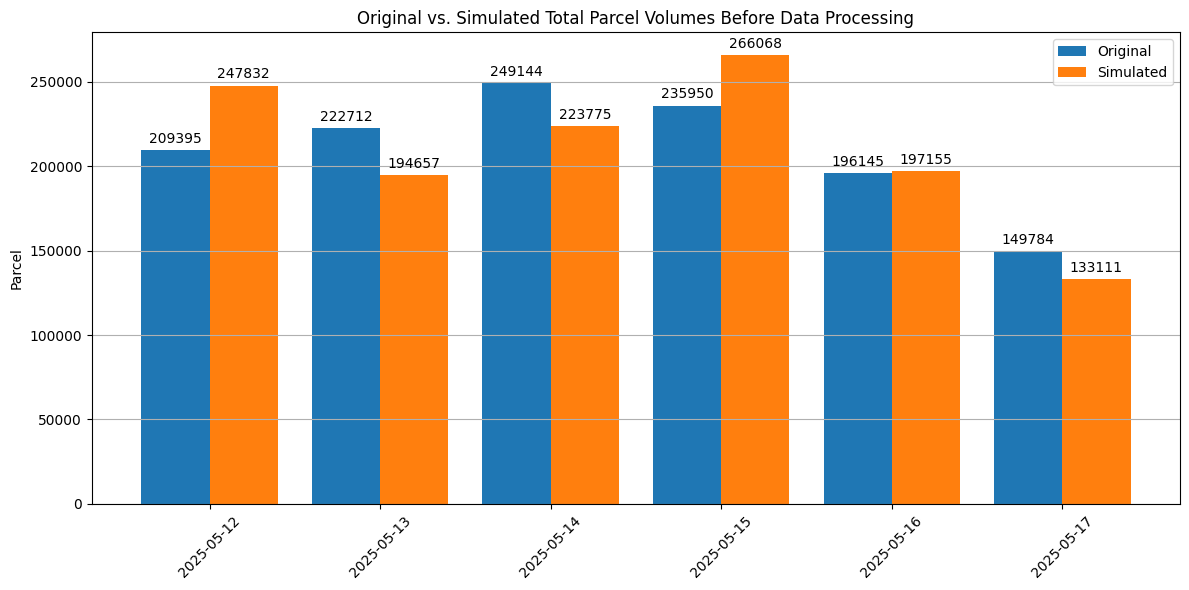

2025-10-05 14:32:22,014 - INFO - Initializing lookup_coords for new_week...
2025-10-05 14:32:37,016 - INFO - Lookup_coords initialized. Loaded 404030 geometries.
2025-10-05 14:32:37,028 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for DHL: B2B=5038, B2C=9024
2025-10-05 14:32:43,033 - INFO - ✅ Validation passed for DHL: totals consistent from None → Monday
2025-10-05 14:32:43,057 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for GLS: B2B=819, B2C=2022
2025-10-05 14:32:44,330 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-10-05 14:32:44,355 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for GLS: B2B=624, B2C=1559
2025-10-05 14:32:45,352 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-10-05 14:32:45,370 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for UPS: B2B=9936, B2C=544
2025-10-05 14:32:47,901 - INFO - ✅ Valid

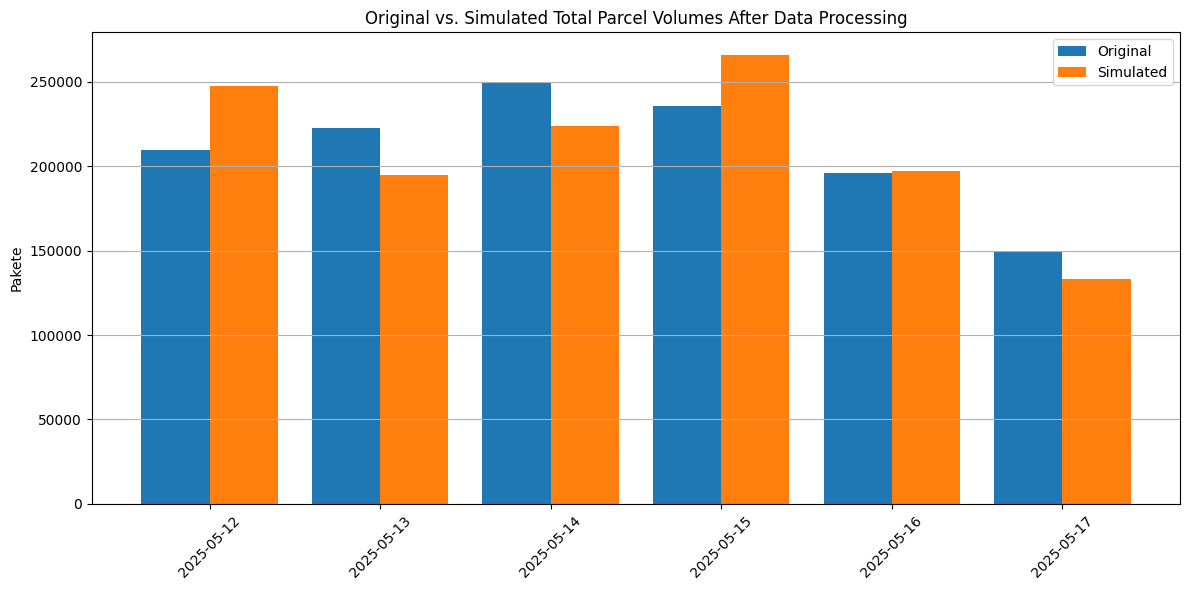

2025-10-05 14:34:05,246 - INFO - ✅ Finished distributing results into new_week
2025-10-05 14:34:05,263 - INFO - Finished simulation for scenario: moderate_cost


In [12]:
new_moderate_week = simulate_full_existing_week(deepcopy(hagrid_files), days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='moderate_cost')

2025-10-05 14:34:05,398 - INFO - ================================================================================
2025-10-05 14:34:05,399 - INFO - STARTING WEEKLY SIMULATION FOR SCENARIO: MEDIUM_COST
2025-10-05 14:34:05,400 - INFO - ================================================================================
2025-10-05 14:34:05,482 - INFO - Loaded and initialized data for Monday.
2025-10-05 14:34:05,495 - INFO - Loaded and initialized data for Tuesday.
2025-10-05 14:34:05,505 - INFO - Loaded and initialized data for Wednesday.
2025-10-05 14:34:05,514 - INFO - Loaded and initialized data for Thursday.
2025-10-05 14:34:05,522 - INFO - Loaded and initialized data for Friday.
2025-10-05 14:34:05,532 - INFO - Loaded and initialized data for Saturday.
2025-10-05 14:34:05,534 - INFO - ============================================================
2025-10-05 14:34:05,534 - INFO -  *** START BATCH SIMULATION FOR: MONDAY *** 
2025-10-05 14:34:05,535 - INFO - ===================================

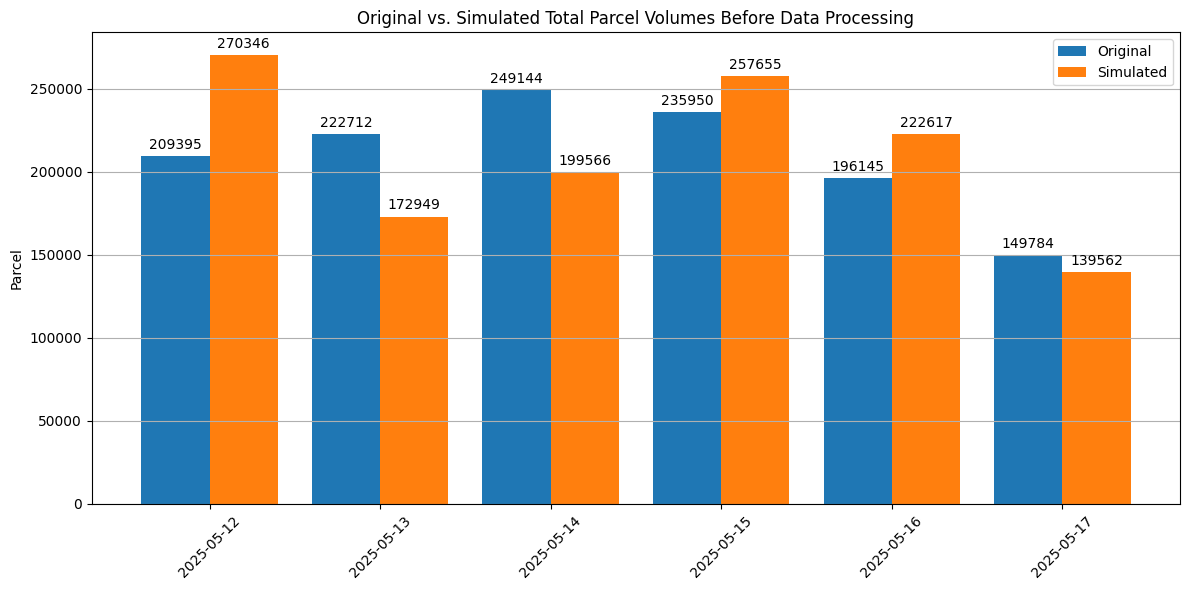

2025-10-05 14:34:06,471 - INFO - Initializing lookup_coords for new_week...
2025-10-05 14:34:24,897 - INFO - Lookup_coords initialized. Loaded 404030 geometries.
2025-10-05 14:34:24,920 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for DHL: B2B=7045, B2C=42486
2025-10-05 14:35:03,989 - INFO - ✅ Validation passed for DHL: totals consistent from None → Monday
2025-10-05 14:35:04,028 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for GLS: B2B=1149, B2C=9489
2025-10-05 14:35:10,039 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-10-05 14:35:10,066 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for GLS: B2B=874, B2C=7249
2025-10-05 14:35:14,282 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-10-05 14:35:14,314 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for UPS: B2B=13901, B2C=2574
2025-10-05 14:35:21,630 - INFO - ✅ V

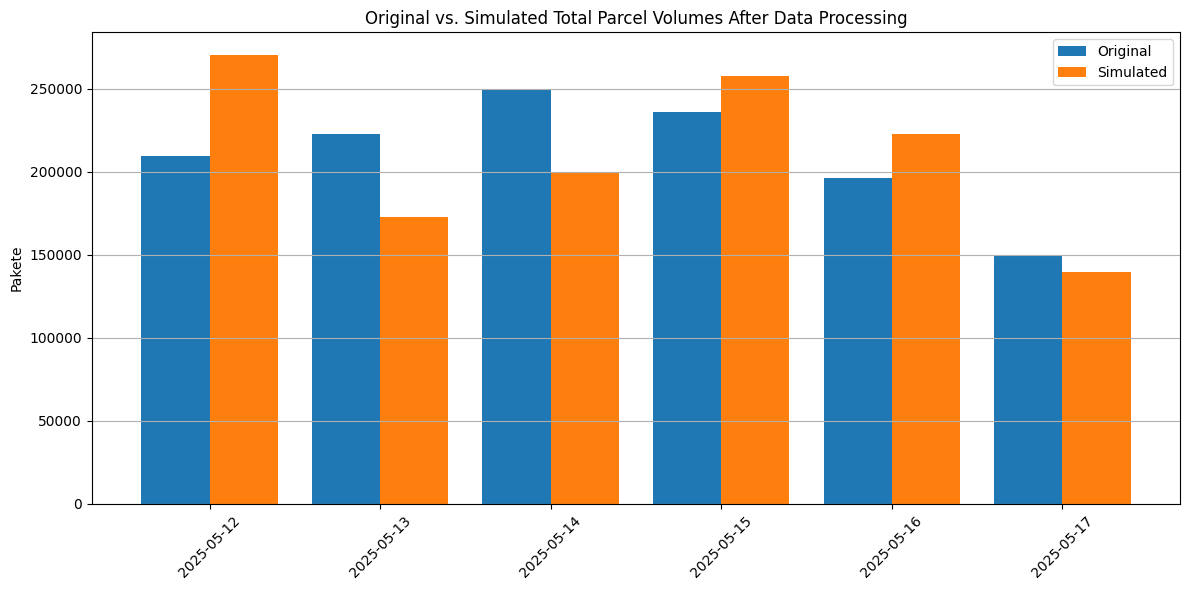

2025-10-05 14:38:55,225 - INFO - ✅ Finished distributing results into new_week
2025-10-05 14:38:55,233 - INFO - Finished simulation for scenario: medium_cost


In [13]:
new_medium_week = simulate_full_existing_week(deepcopy(hagrid_files), days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='medium_cost')

2025-10-05 14:38:55,344 - INFO - ================================================================================
2025-10-05 14:38:55,344 - INFO - STARTING WEEKLY SIMULATION FOR SCENARIO: HIGH_COST
2025-10-05 14:38:55,345 - INFO - ================================================================================
2025-10-05 14:38:55,402 - INFO - Loaded and initialized data for Monday.
2025-10-05 14:38:55,409 - INFO - Loaded and initialized data for Tuesday.
2025-10-05 14:38:55,416 - INFO - Loaded and initialized data for Wednesday.
2025-10-05 14:38:55,423 - INFO - Loaded and initialized data for Thursday.
2025-10-05 14:38:55,430 - INFO - Loaded and initialized data for Friday.
2025-10-05 14:38:55,436 - INFO - Loaded and initialized data for Saturday.
2025-10-05 14:38:55,436 - INFO - ============================================================
2025-10-05 14:38:55,436 - INFO -  *** START BATCH SIMULATION FOR: MONDAY *** 
2025-10-05 14:38:55,437 - INFO - =====================================

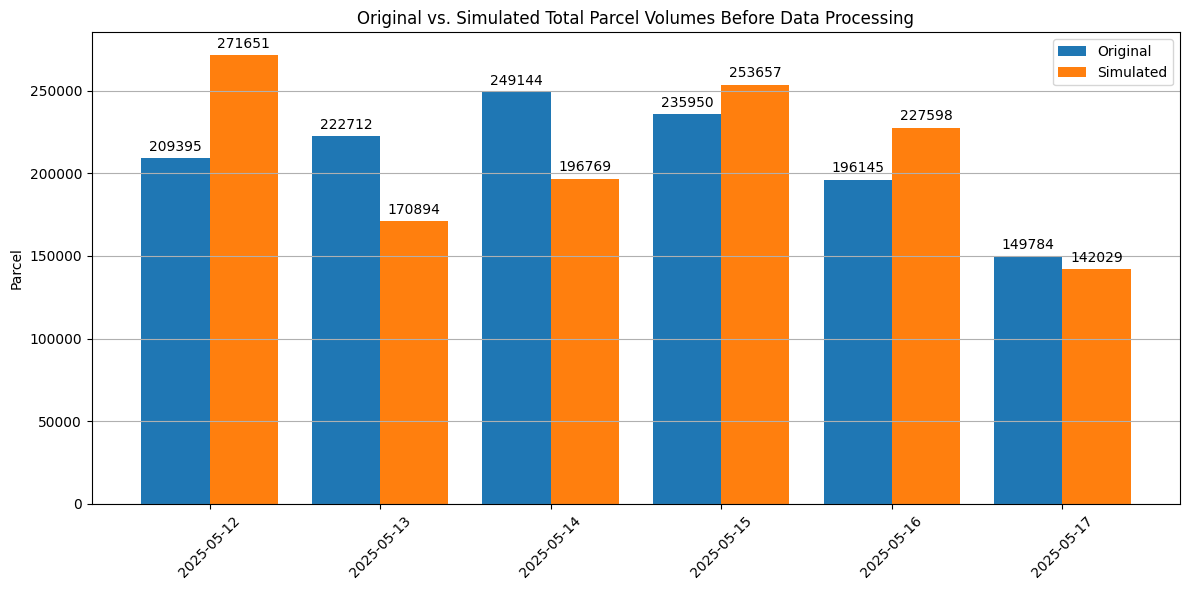

2025-10-05 14:38:56,121 - INFO - Initializing lookup_coords for new_week...
2025-10-05 14:39:10,904 - INFO - Lookup_coords initialized. Loaded 404030 geometries.
2025-10-05 14:39:10,916 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for DHL: B2B=7045, B2C=48199
2025-10-05 14:39:31,404 - INFO - ✅ Validation passed for DHL: totals consistent from None → Monday
2025-10-05 14:39:31,430 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for GLS: B2B=1149, B2C=10812
2025-10-05 14:39:34,242 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-10-05 14:39:34,260 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for GLS: B2B=874, B2C=8244
2025-10-05 14:39:36,298 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-10-05 14:39:36,316 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for UPS: B2B=13903, B2C=2919
2025-10-05 14:39:39,598 - INFO - ✅ 

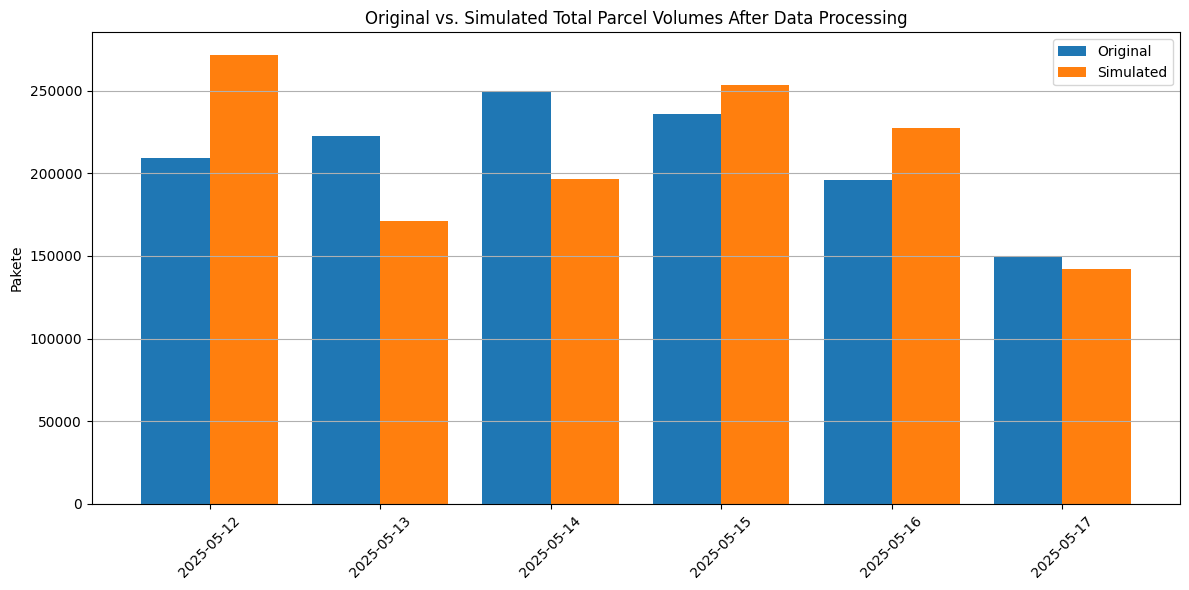

2025-10-05 14:43:04,350 - INFO - ✅ Finished distributing results into new_week
2025-10-05 14:43:04,360 - INFO - Finished simulation for scenario: high_cost


In [14]:
new_high_week = simulate_full_existing_week(deepcopy(hagrid_files), days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='high_cost')

2025-10-05 14:43:04,469 - INFO - ================================================================================
2025-10-05 14:43:04,470 - INFO - STARTING WEEKLY SIMULATION FOR SCENARIO: FULL_SCENARIO
2025-10-05 14:43:04,471 - INFO - ================================================================================
2025-10-05 14:43:04,522 - INFO - Loaded and initialized data for Monday.
2025-10-05 14:43:04,528 - INFO - Loaded and initialized data for Tuesday.
2025-10-05 14:43:04,535 - INFO - Loaded and initialized data for Wednesday.
2025-10-05 14:43:04,543 - INFO - Loaded and initialized data for Thursday.
2025-10-05 14:43:04,550 - INFO - Loaded and initialized data for Friday.
2025-10-05 14:43:04,555 - INFO - Loaded and initialized data for Saturday.
2025-10-05 14:43:04,556 - INFO - ============================================================
2025-10-05 14:43:04,557 - INFO -  *** START BATCH SIMULATION FOR: MONDAY *** 
2025-10-05 14:43:04,557 - INFO - =================================

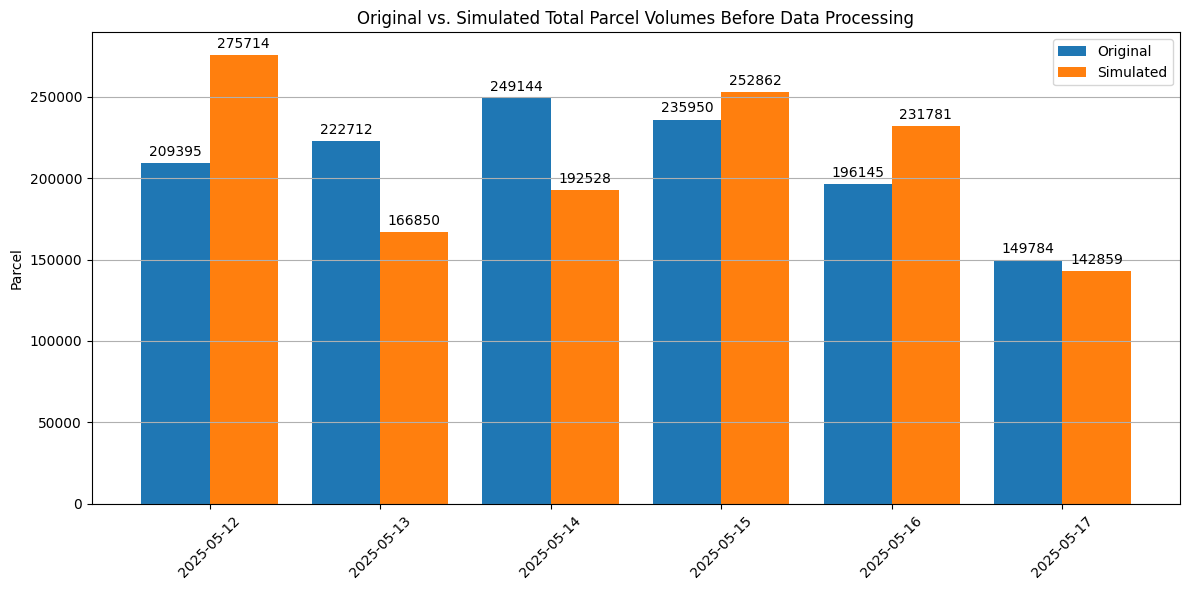

2025-10-05 14:43:05,238 - INFO - Initializing lookup_coords for new_week...
2025-10-05 14:43:20,412 - INFO - Lookup_coords initialized. Loaded 404030 geometries.
2025-10-05 14:43:20,423 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for DHL: B2B=7402, B2C=53803
2025-10-05 14:43:42,763 - INFO - ✅ Validation passed for DHL: totals consistent from None → Monday
2025-10-05 14:43:42,786 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for GLS: B2B=1202, B2C=12048
2025-10-05 14:43:45,711 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-10-05 14:43:45,730 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for GLS: B2B=911, B2C=9196
2025-10-05 14:43:47,901 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-10-05 14:43:47,918 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for UPS: B2B=14649, B2C=3281
2025-10-05 14:43:51,375 - INFO - ✅ 

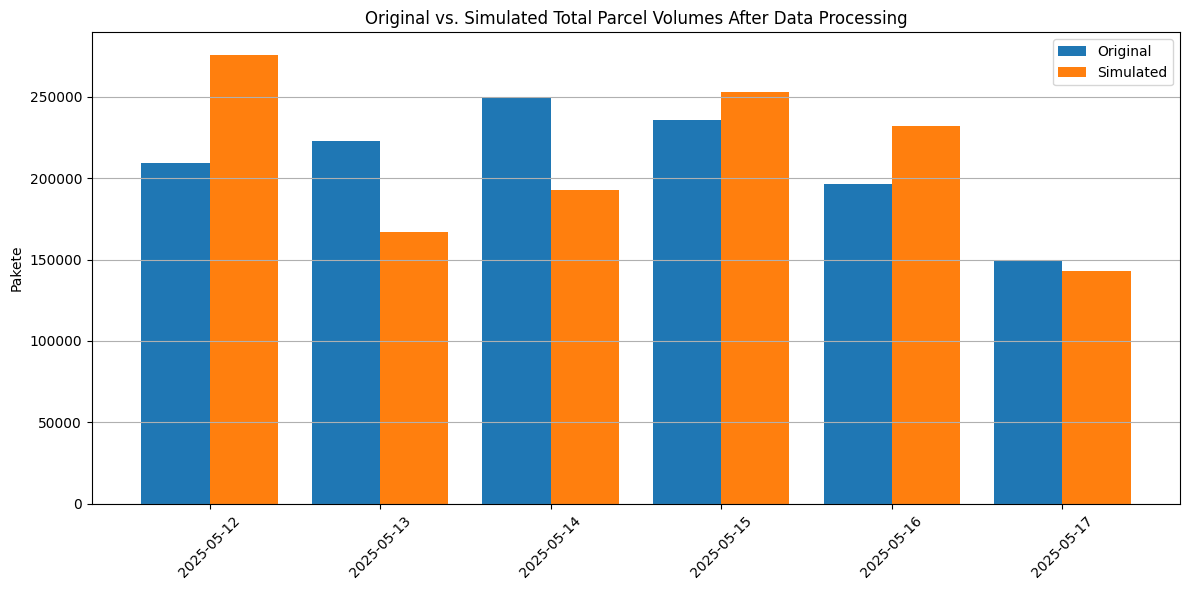

2025-10-05 14:47:30,496 - INFO - ✅ Finished distributing results into new_week
2025-10-05 14:47:30,506 - INFO - Finished simulation for scenario: full_scenario


In [15]:
new_full_week = simulate_full_existing_week(deepcopy(hagrid_files), days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='full_scenario')

In [16]:
def prepare_old_week(hagrid_files_thisweek, days, base_date):
    """
    Prepares the old (original) week from hagrid_files without simulation changes.
    Calculates wl_tag and total fields.
    """
    old_week = {}

    for i, day in enumerate(days):
        date_str = (base_date + datetime.timedelta(days=i)).strftime("%Y-%m-%d")
        key = f"hagrid_parcel_demand_{date_str}_({day})"
        if key not in hagrid_files_thisweek:
            raise KeyError(f"Missing file for {key}.")
        
        df = hagrid_files_thisweek[key].copy() 

        old_week[day] = df

    return old_week

def plot_wltag_comparison(old_week, new_week, old_label="Old Week", new_label="New Week"):
    """
    Plots the total wl_tag per day for old and new weeks for comparison.
    """
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    
    old_totals = []
    new_totals = []

    for day in days:
        old_df = old_week.get(day)
        new_df = new_week.get(day)

        if old_df is not None:
            old_total = old_df['wl_tag'].sum()
        else:
            old_total = 0

        if new_df is not None:
            new_total = new_df['wl_tag'].sum()
        else:
            new_total = 0

        old_totals.append(old_total)
        new_totals.append(new_total)

    for carrier in carrier_columns:
        prefix, _, _ = carrier_columns[carrier]
        old_sum = old_week['Tuesday'][f"{prefix}_b2b"].sum() + old_week['Tuesday'][f"{prefix}_b2c"].sum()
        new_sum = new_week['Tuesday'][f"{prefix}_b2b"].sum() + new_week['Tuesday'][f"{prefix}_b2c"].sum()
        print(f"Tuesday {carrier}: old={old_sum}, new={new_sum}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(days, old_totals, marker='o', label=old_label)
    plt.plot(days, new_totals, marker='o', label=new_label)

    plt.title("Comparison of wl_tag Totals per Day", fontsize=14)
    plt.xlabel("Day of Week", fontsize=12)
    plt.ylabel("Total wl_tag (Deliveries)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

old_week = prepare_old_week(hagrid_files, days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], base_date = datetime.date(2025, 5, 12))

old_week


{'Monday':       str_idx                name postal_cod  cell_id  total_sim  ama_b2b  \
 0           0    Aegidienkirchhof      30159   8611.0          7        0   
 1           0    Aegidienkirchhof      30159   8611.0          5        0   
 2           1     Alexanderstraße      30159   9181.0          8        0   
 3           1     Alexanderstraße      30159   9181.0          2        0   
 4           2       Am Hohen Ufer      30159   8613.0          5        0   
 ...       ...                 ...        ...      ...        ...      ...   
 67746   12340      Ziegeleistraße      30855   7431.0          7        0   
 67747   12340      Ziegeleistraße      30855   7431.0         12        0   
 67748   12340      Ziegeleistraße      30855   7061.0          6        0   
 67749   12340      Ziegeleistraße      30855   7061.0          3        0   
 67750   12341  Zur Schnittenriede      30855   9347.0          2        0   
 
        ama_b2c  dhl_b2b  dhl_b2c  dpd_b2b  ...  fed

In [17]:
import numpy as np
import pandas as pd
import logging
from typing import Dict, Tuple

def _flow_cols(df: pd.DataFrame) -> list:
    return [c for c in df.columns if c.endswith("_b2b") or c.endswith("_b2c")]

def apply_type_tag_and_totals_no_rename(
    new_week: Dict[str, pd.DataFrame],
    carrier_columns: Dict[str, Tuple[str, str, str]],
    logger: logging.Logger | None = None,
    scenario_name: str = "unknown"
) -> Dict[str, pd.DataFrame]:
    """
    Do not change column names.
    For each provider:
      copy <prefix>_b2b -> type_col      (from carrier_columns)
      copy <prefix>_b2c -> tag_col       (from carrier_columns)
    Then set:
      wl_tag   = row sum over all tag and type columns
      total_sim= row sum over all *_b2b and *_b2c
      total    = total_sim
    Assertions per day:
      sum(all *_b2b) == sum(all type cols)
      sum(all *_b2c) == sum(all tag cols)
      sum(wl_tag) == sum(all flows) == sum(total_sim) == sum(total)
      no NaN and no negatives in flows, tag, type, totals
      integer values or floats that are integer valued
    Operates on copies and returns modified dict.
    """
    log = logger if logger is not None else logging.getLogger(__name__)

    for day, df in new_week.items():
        log.info("Start edit for scenario=%s | day=%s", scenario_name, day)
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"{scenario_name} {day}: input is not a DataFrame")

        df = df.copy()

        # 1) copy flows into existing tag/type columns as given in carrier_columns
        b2b_cols = []
        b2c_cols = []
        type_cols = []
        tag_cols = []

        for provider, (prefix, tag_col, type_col) in carrier_columns.items():
            src_b2b = f"{prefix}_b2b"
            src_b2c = f"{prefix}_b2c"

            if src_b2b in df.columns:
                df[type_col] = df[src_b2b].fillna(0).astype(int)
                b2b_cols.append(src_b2b)
                type_cols.append(type_col)
            else:
                log.info("[%s|%s] missing column %s for type copy", scenario_name, day, src_b2b)

            if src_b2c in df.columns:
                df[tag_col] = df[src_b2c].fillna(0).astype(int)
                b2c_cols.append(src_b2c)
                tag_cols.append(tag_col)
            else:
                log.info("[%s|%s] missing column %s for tag copy", scenario_name, day, src_b2c)

        # 2) immediate checks for copy correctness
        b2b_sum = int(df[b2b_cols].sum().sum()) if b2b_cols else 0
        type_sum = int(df[type_cols].sum().sum()) if type_cols else 0
        if b2b_sum != type_sum:
            raise AssertionError(f"{scenario_name} {day}: sum(b2b) {b2b_sum} != sum(type) {type_sum}")

        b2c_sum = int(df[b2c_cols].sum().sum()) if b2c_cols else 0
        tag_sum = int(df[tag_cols].sum().sum()) if tag_cols else 0
        if b2c_sum != tag_sum:
            raise AssertionError(f"{scenario_name} {day}: sum(b2c) {b2c_sum} != sum(tag) {tag_sum}")

        # 3) totals
        flow_cols = _flow_cols(df)
        df["total_sim"] = df[flow_cols].sum(axis=1) if flow_cols else 0
        df["total"] = df["total_sim"]
        all_type_tag = tag_cols + type_cols
        df["wl_tag"] = df[all_type_tag].sum(axis=1) if all_type_tag else 0

        # 4) grand total checks
        flows_total = int(df[flow_cols].sum().sum()) if flow_cols else 0
        wl_tag_total = int(df["wl_tag"].sum()) if "wl_tag" in df.columns else 0
        total_sim_total = int(df["total_sim"].sum()) if "total_sim" in df.columns else 0
        total_total = int(df["total"].sum()) if "total" in df.columns else 0

        if not (flows_total == wl_tag_total == total_sim_total == total_total):
            raise AssertionError(
                f"{scenario_name} {day}: mismatch totals flows={flows_total} wl_tag={wl_tag_total} total_sim={total_sim_total} total={total_total}"
            )

        # 5) quality checks
        cols_check = flow_cols + all_type_tag + ["total_sim", "total", "wl_tag"]
        if cols_check:
            if df[cols_check].isna().any().any():
                raise AssertionError(f"{scenario_name} {day}: NaN detected in {cols_check}")
            if (df[cols_check] < 0).any().any():
                raise AssertionError(f"{scenario_name} {day}: negative values detected in {cols_check}")
            # integerish check
            non_integer_cols = []
            for c in cols_check:
                if not np.issubdtype(df[c].dtype, np.integer):
                    if not np.isclose(df[c] % 1, 0).all():
                        non_integer_cols.append(c)
            if non_integer_cols:
                raise AssertionError(f"{scenario_name} {day}: non integer values in {non_integer_cols}")

        new_week[day] = df
        log.info("Finished edit for scenario=%s | day=%s totals=%d", scenario_name, day, total_total)

    return new_week

scenarios = {
    "full": new_full_week,
    "high": new_high_week,
    "medium": new_medium_week,
    "moderate": new_moderate_week,
}

for name, week in scenarios.items():
    scenarios[name] = apply_type_tag_and_totals_no_rename(
        new_week=week,
        carrier_columns=carrier_columns,
        logger=LOGGER,
        scenario_name=name
    )
    LOGGER.info("Edit completed for scenario %s", name)

# optional zurückschreiben
new_full_week = scenarios["full"]
new_high_week = scenarios["high"]
new_medium_week = scenarios["medium"]
new_moderate_week = scenarios["moderate"]



2025-10-05 14:47:30,734 - INFO - Start edit for scenario=full | day=Monday
2025-10-05 14:47:30,849 - INFO - Finished edit for scenario=full | day=Monday totals=275714
2025-10-05 14:47:30,853 - INFO - Start edit for scenario=full | day=Tuesday
2025-10-05 14:47:30,967 - INFO - Finished edit for scenario=full | day=Tuesday totals=166850
2025-10-05 14:47:30,971 - INFO - Start edit for scenario=full | day=Wednesday
2025-10-05 14:47:31,089 - INFO - Finished edit for scenario=full | day=Wednesday totals=192528
2025-10-05 14:47:31,093 - INFO - Start edit for scenario=full | day=Thursday
2025-10-05 14:47:31,214 - INFO - Finished edit for scenario=full | day=Thursday totals=252862
2025-10-05 14:47:31,218 - INFO - Start edit for scenario=full | day=Friday
2025-10-05 14:47:31,332 - INFO - Finished edit for scenario=full | day=Friday totals=231781
2025-10-05 14:47:31,336 - INFO - Start edit for scenario=full | day=Saturday
2025-10-05 14:47:31,441 - INFO - Finished edit for scenario=full | day=Satur

In [18]:
new_moderate_week.get("Monday")["amazon_typ"].sum()

np.int64(91)

In [19]:
import os
import logging
from typing import Dict
import geopandas as gpd
import pandas as pd
from shapely.geometry.base import BaseGeometry

# ----------------------------------------------------------------------
# Logging setup
# ----------------------------------------------------------------------
if not logging.getLogger().handlers:
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

# ----------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------
def _normalize_gdf(df: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Ensure a consistent geometry and CRS.
    - Use 'point_geom' as active geometry if present, otherwise keep current geometry.
    - Set CRS to EPSG:25832 if missing.
    - Drop any extra geometry-like columns other than the active one.
    """
    if "point_geom" in df.columns:
        z = df.set_geometry("point_geom").copy()
    else:
        z = df.copy()
        if z.geometry.name is None:
            raise ValueError("No active geometry set and no 'point_geom' column available.")

    if z.crs is None:
        logging.warning("No CRS found on GeoDataFrame. Setting CRS to EPSG:25832.")
        z.set_crs("EPSG:25832", inplace=True, allow_override=True)

    for col in list(z.columns):
        if col == z.geometry.name:
            continue
        if len(z) > 0:
            first = z[col].iloc[0]
            if isinstance(first, BaseGeometry):
                z = z.drop(columns=[col])

    return z


def export_gdf(df: gpd.GeoDataFrame, out_path: str, driver: str):
    """Export a GeoDataFrame directly to a file with the given driver."""
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    z = _normalize_gdf(df)
    logging.info("Writing %s to %s", driver, out_path)
    z.to_file(out_path, driver=driver)
    return out_path


def export_csv(df: gpd.GeoDataFrame, out_path: str):
    """Export a GeoDataFrame to CSV with geometry as WKT."""
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    z = _normalize_gdf(df)
    df_csv = z.copy()
    df_csv["geometry"] = df_csv.geometry.apply(lambda g: g.wkt if g is not None else None)
    logging.info("Writing CSV to %s", out_path)
    df_csv.to_csv(out_path, index=False)
    return out_path


def _num_series(s: pd.Series) -> pd.Series:
    """Convert a Series to numeric with NaN to 0."""
    return pd.to_numeric(s, errors="coerce").fillna(0)

# ----------------------------------------------------------------------
# Formats and main loop
# ----------------------------------------------------------------------
formats = {
    "shp":  ("ESRI Shapefile", ".shp"),
    "gpkg": ("GPKG", ".gpkg"),
    "geojson": ("GeoJSON", ".geojson"),
}

scenarios = [
    ("Moderate Cost", new_moderate_week),
    ("Medium Cost", new_medium_week),
    ("High Cost", new_high_week),
    ("Full", new_full_week),
]

weekday_name_map = {
    "Monday":    "hagrid_parcel_demand_2025-05-12_(Monday)",
    "Tuesday":   "hagrid_parcel_demand_2025-05-13_(Tuesday)",
    "Wednesday": "hagrid_parcel_demand_2025-05-14_(Wednesday)",
    "Thursday":  "hagrid_parcel_demand_2025-05-15_(Thursday)",
    "Friday":    "hagrid_parcel_demand_2025-05-16_(Friday)",
    "Saturday":  "hagrid_parcel_demand_2025-05-17_(Saturday)",
}

# Dictionary to collect all exported file paths
exported_files: Dict[str, Dict[str, Dict[str, str]]] = {}

for scenario_name, week_dict in scenarios:
    scenario_dir = os.path.join("output", "batchdelivery", scenario_name)
    os.makedirs(scenario_dir, exist_ok=True)
    logging.info("Exporting scenario '%s' into %s", scenario_name, scenario_dir)

    exported_files[scenario_name] = {}

    for weekday, gdf in week_dict.items():
        if weekday not in weekday_name_map:
            logging.warning("Weekday '%s' not in weekday_name_map. Skipping.", weekday)
            continue

        stem = weekday_name_map[weekday]
        exported_files[scenario_name][weekday] = {}

        # Geo formats
        for fmt, (driver, ext) in formats.items():
            out_path = os.path.join(scenario_dir, stem + ext)
            export_gdf(gdf, out_path, driver=driver)
            exported_files[scenario_name][weekday][fmt] = out_path

        # CSV
        csv_path = os.path.join(scenario_dir, stem + ".csv")
        export_csv(gdf, csv_path)
        exported_files[scenario_name][weekday]["csv"] = csv_path


# After the loop, you can access all paths like:
# exported_files["Moderate Cost"]["Monday"]["shp"]
# exported_files["Full"]["Friday"]["csv"]


2025-10-05 14:47:33,608 - INFO - Exporting scenario 'Moderate Cost' into output\batchdelivery\Moderate Cost
2025-10-05 14:47:33,628 - WARNING - No CRS found on GeoDataFrame. Setting CRS to EPSG:25832.
2025-10-05 14:47:33,630 - INFO - Writing ESRI Shapefile to output\batchdelivery\Moderate Cost\hagrid_parcel_demand_2025-05-12_(Monday).shp
2025-10-05 14:47:35,858 - INFO - Created 78,029 records
2025-10-05 14:47:35,882 - WARNING - No CRS found on GeoDataFrame. Setting CRS to EPSG:25832.
2025-10-05 14:47:35,885 - INFO - Writing GPKG to output\batchdelivery\Moderate Cost\hagrid_parcel_demand_2025-05-12_(Monday).gpkg
2025-10-05 14:47:37,267 - INFO - Created 78,029 records
2025-10-05 14:47:37,420 - WARNING - No CRS found on GeoDataFrame. Setting CRS to EPSG:25832.
2025-10-05 14:47:37,423 - INFO - Writing GeoJSON to output\batchdelivery\Moderate Cost\hagrid_parcel_demand_2025-05-12_(Monday).geojson
2025-10-05 14:47:41,075 - INFO - Created 78,029 records
2025-10-05 14:47:41,099 - WARNING - No C

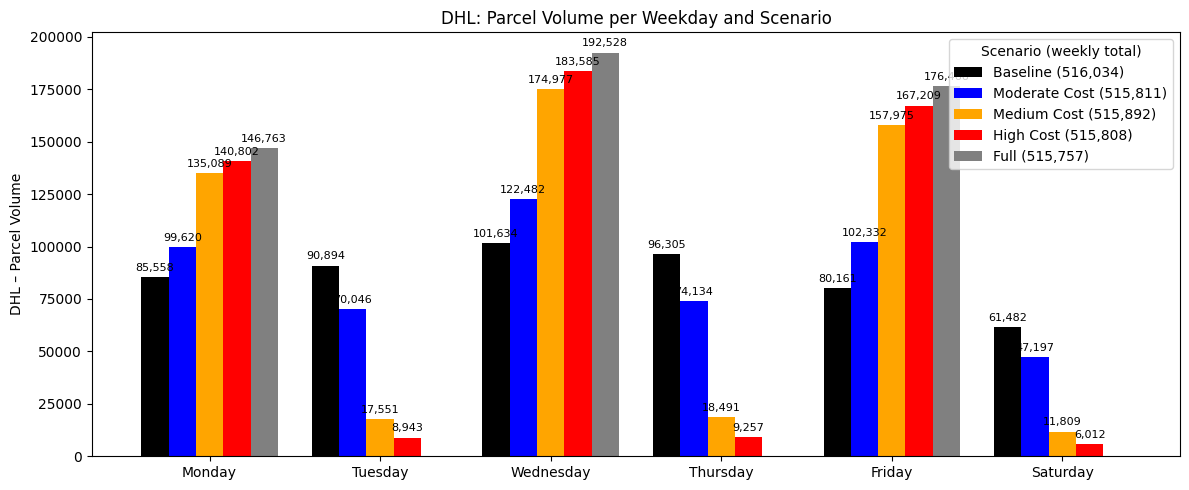

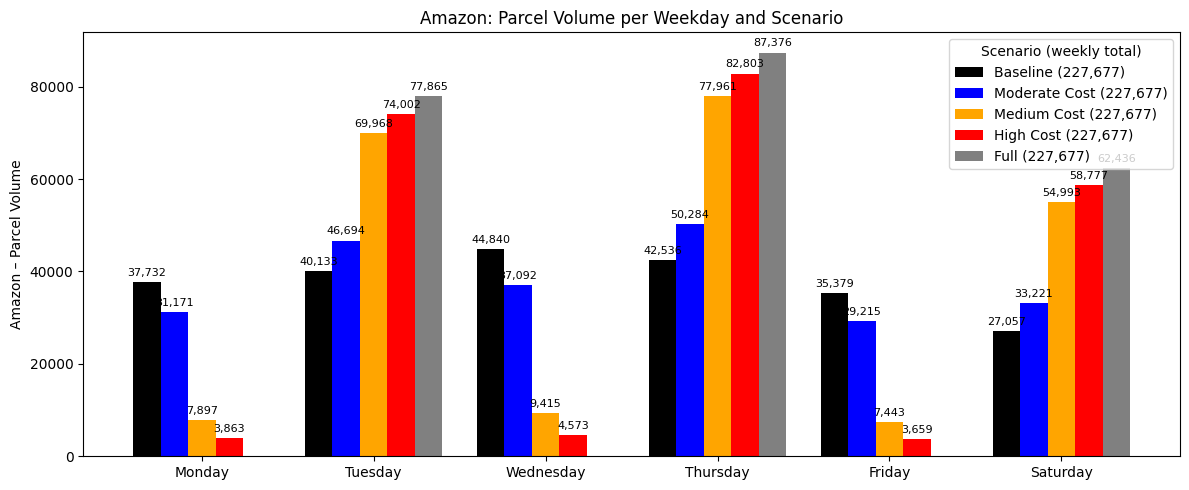

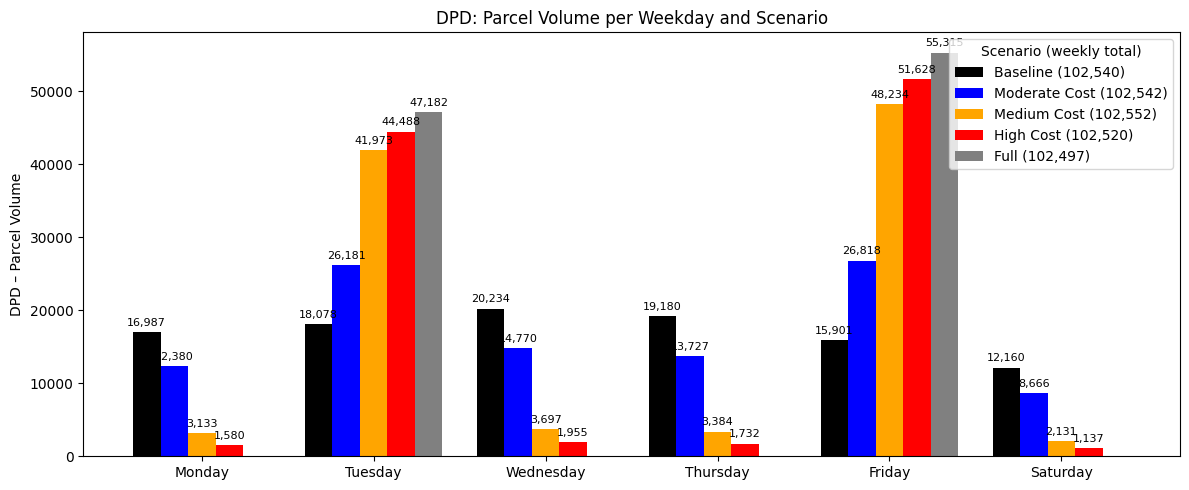

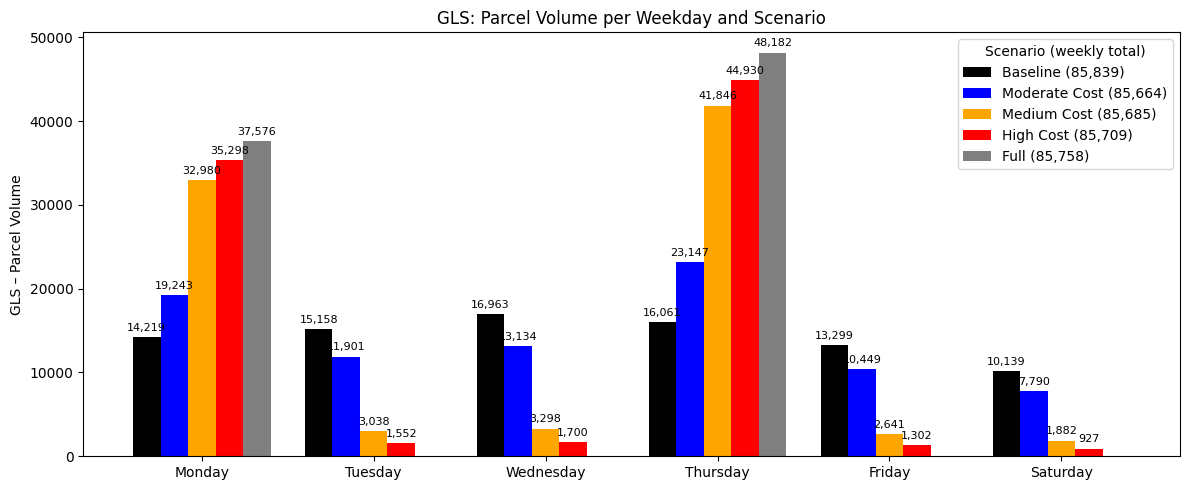

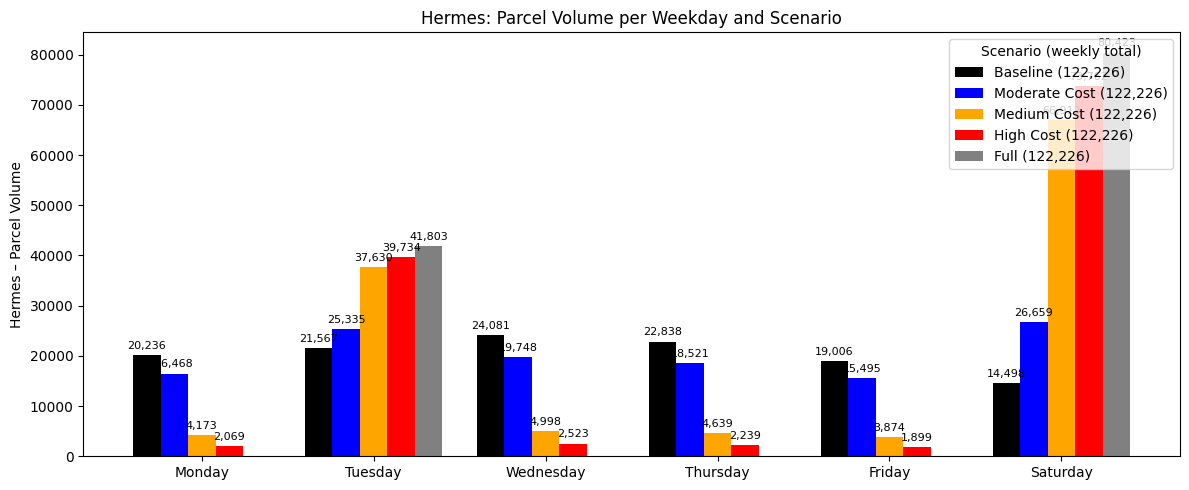

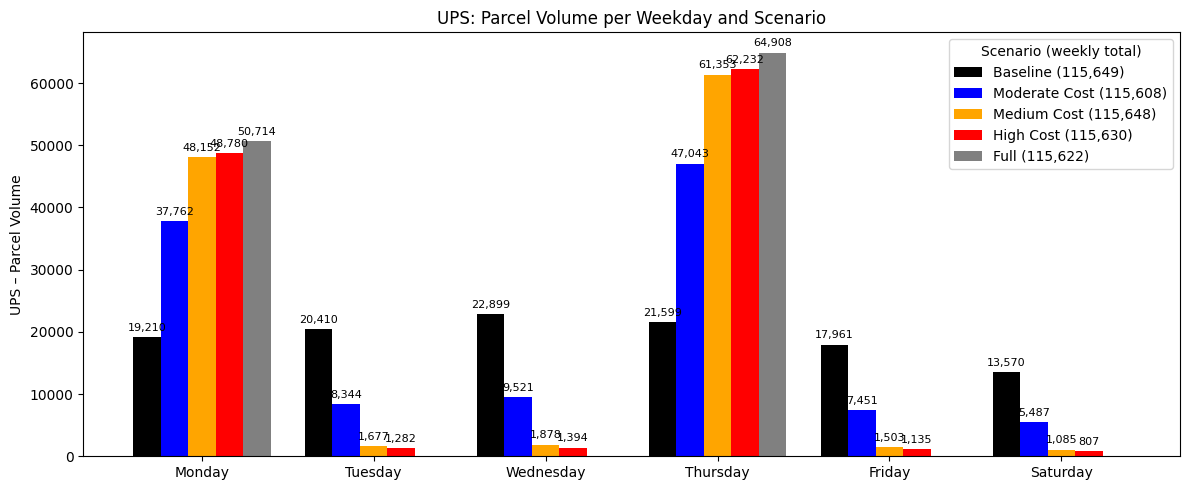

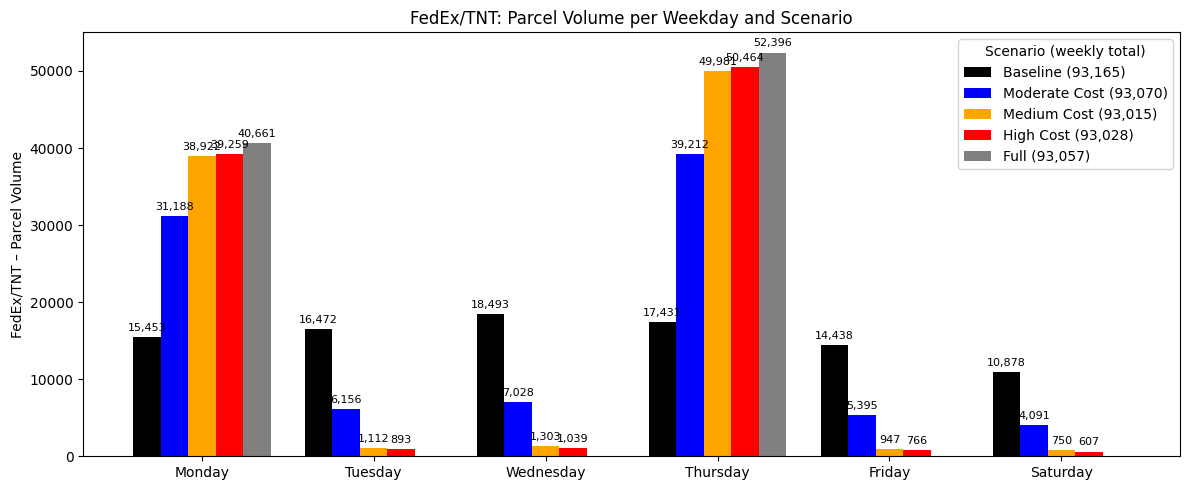

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Szenarien definieren
scenarios = [
    ("Baseline", old_week),
    ("Moderate Cost", new_moderate_week),
    ("Medium Cost", new_medium_week),
    ("High Cost", new_high_week),
    ("Full", new_full_week)
]

# Farben definieren
colors = {
    "Baseline": "black",
    "Moderate Cost": "blue",
    "Medium Cost": "orange",
    "High Cost": "red",
    "Full": "grey"
}

# Wochentage
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
day_map = {day: i for i, day in enumerate(weekdays)}

# Paketdienstleister
carriers = {
    "DHL": ("dhl_b2b", "dhl_b2c"),
    "Amazon": ("ama_b2b", "ama_b2c"),
    "DPD": ("dpd_b2b", "dpd_b2c"),
    "GLS": ("gls_b2b", "gls_b2c"),
    "Hermes": ("her_b2b", "her_b2c"),
    "UPS": ("ups_b2b", "ups_b2c"),
    "FedEx/TNT": ("fxt_b2b", "fxt_b2c")
}

# Plot pro Carrier
for carrier, (col_b2b, col_b2c) in carriers.items():
    records = []
    total_per_scenario = {}
    
    for scen_name, weekdict in scenarios:
        week_total = 0
        for day in weekdays:
            gdf = weekdict.get(day)
            if gdf is not None and col_b2b in gdf.columns and col_b2c in gdf.columns:
                total = gdf[col_b2b].sum() + gdf[col_b2c].sum()
                records.append({'Scenario': scen_name, 'Day': day, 'Total': total})
                week_total += total
        total_per_scenario[scen_name] = week_total

    df = pd.DataFrame(records)
    
    if df.empty:
        print(f"Skipping {carrier} – no data.")
        continue

    df["Day_idx"] = df["Day"].map(day_map)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    bar_width = 0.16
    x = np.arange(len(weekdays))
    offsets = [-2, -1, 0, 1, 2]

    for (scenario, _), offset in zip(scenarios, offsets):
        df_scen = df[df["Scenario"] == scenario].sort_values("Day_idx")
        bars = ax.bar(x + offset * bar_width, df_scen["Total"], width=bar_width,
                      label=f"{scenario} ({int(total_per_scenario[scenario]):,})",
                      color=colors[scenario])

        # Annotate bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.annotate(f'{int(height):,}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(weekdays)
    ax.set_ylabel(f"{carrier} – Parcel Volume")
    ax.set_title(f"{carrier}: Parcel Volume per Weekday and Scenario")
    ax.legend(title="Scenario (weekly total)", loc="upper right")
    plt.tight_layout()
    plt.show()


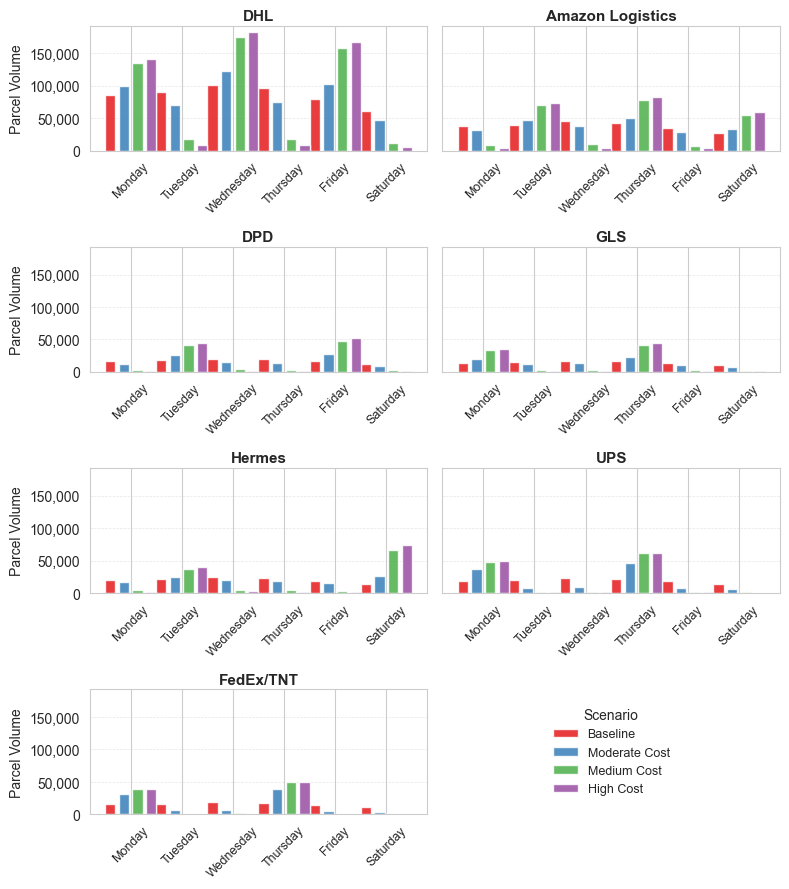

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

def thousands_us(x, pos):
    return f"{int(x):,}"

plt.style.use("default")
sns.set_style("whitegrid")

# Liste der LSPs aus carrier_columns (dein bestehendes Mapping)
selected_lsps = ["DHL", "Amazon", "DPD", "GLS", "Hermes", "UPS", "FedEx/TNT"]
carrier_columns = {
    "Amazon": ('ama', 'amazon_tag', 'amazon_typ'),
    "DHL": ('dhl', 'dhl_tag', 'dhl_type'),
    "DPD": ('dpd', 'dpd_tag', 'dpd_type'),
    "GLS": ('gls', 'gls_tag', 'gls_type'),
    "Hermes": ('her', 'hermes_tag', 'hermes_typ'),
    "UPS": ('ups', 'ups_tag', 'ups_type'),
    "FedEx/TNT": ('fxt', 'fedex_tag', 'fedex_type')
}

# Szenarien
scenarios = [
    ("Baseline", old_week),
    ("Moderate Cost", new_moderate_week),
    ("Medium Cost", new_medium_week),
    ("High Cost", new_high_week)
]

colors = {
    "Baseline": "black",
    "Moderate Cost": "blue",
    "Medium Cost": "orange",
    "High Cost": "red",
    "Full": "grey"
}

weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

# Datensammlung für alle Carrier
records = []
for scen_name, weekdict in scenarios:
    for carrier in selected_lsps:
        prefix = carrier_columns[carrier][0]
        for day in weekdays:
            gdf = weekdict.get(day)
            if gdf is not None:
                total = gdf[f"{prefix}_b2b"].sum() + gdf[f"{prefix}_b2c"].sum()
                records.append({
                    "Carrier": carrier,
                    "Scenario": scen_name,
                    "Day": day,
                    "Total": total
                })

df = pd.DataFrame(records)

scenario_order = ['Baseline', 'Moderate Cost', 'Medium Cost', 'High Cost']
selected_lsps = ['DHL', 'Amazon', 'DPD', 'GLS', 'Hermes', 'UPS', 'FedEx/TNT']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

df["Day"] = pd.Categorical(df["Day"], categories=day_order, ordered=True)
df["Scenario"] = pd.Categorical(df["Scenario"], categories=scenario_order, ordered=True)
df = df.sort_values(["Carrier", "Day", "Scenario"])

n = len(selected_lsps)
cols = 2
rows = int(np.ceil((n + 1) / cols))  # +1 für Legende
bar_width = 0.2
x = np.arange(len(day_order))
offsets = np.linspace(-2, 2, num=len(scenario_order)) * bar_width

fig, axes = plt.subplots(rows, cols, figsize=(8, 9), sharey=True)
axes = axes.flatten()

for i, carrier in enumerate(selected_lsps):
    ax = axes[i]
    df_c = df[df["Carrier"] == carrier]

    for j, scenario in enumerate(scenario_order):
        df_scen = df_c[df_c["Scenario"] == scenario].sort_values("Day")
        ax.bar(x + offsets[j], df_scen["Total"], width=bar_width,
               label=scenario if i == 0 else "", color=colors[scenario], alpha=0.85)

    carrier_label = "Amazon Logistics" if carrier == "Amazon" else carrier
    ax.set_title(carrier_label, fontsize=11, fontweight="bold", pad=4)
    ax.set_xticks(x)
    ax.set_xticklabels(day_order, rotation=45, fontsize=9)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_us))

    if i % cols == 0:
        ax.set_ylabel("Parcel Volume", fontsize=10)

# Legendenachse mittig platzieren (mittleres Feld der unteren Reihe)
legend_ax_index = len(selected_lsps)
middle_col = 1  # Spalte 2 (nullbasiert)
middle_row = rows
middle_index = 7

legend_ax = axes[middle_index]
legend_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, title="Scenario",
                 loc="center", fontsize=9, title_fontsize=10, frameon=False)

# Alle weiteren ungenutzten Achsen ausblenden
for j in range(len(selected_lsps), len(axes)):
    if j != middle_index:
        fig.delaxes(axes[j])

plt.tight_layout()

# plt.savefig("output/parcel_volume_comparison_all_carriers.pdf", dpi=300)
plt.show()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_15004\3219225065.py:47: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:25832

  joined = gpd.sjoin(gdf_scen, grid, how="inner", predicate="intersects")
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_15004\3219225065.py:47: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:25832

  joined = gpd.sjoin(gdf_scen, grid, how="inner", predicate="intersects")
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_15004\3219225065.py:47: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS

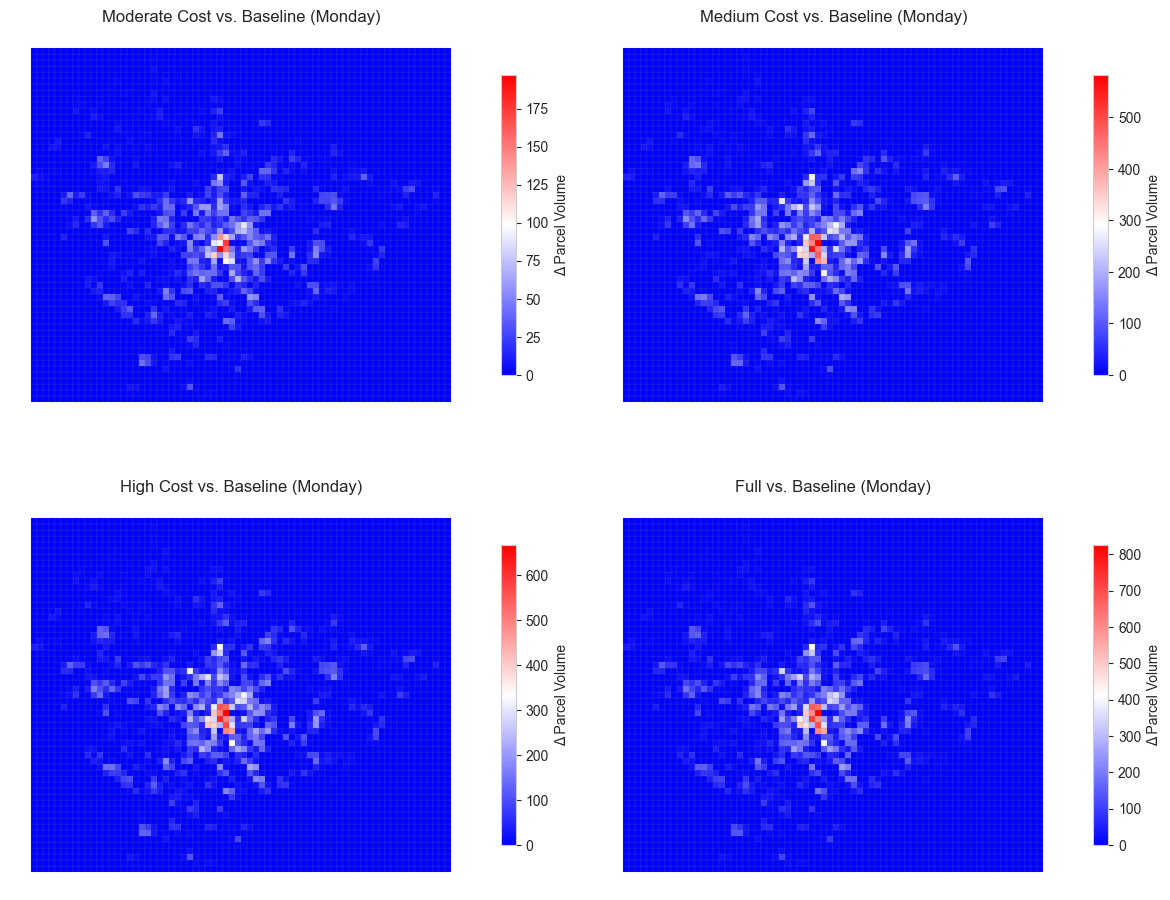

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import box

# 1. Grundlage: Montag aus Baseline (old_week)
gdf_base = old_week["Monday"].copy()
gdf_base["Total"] = gdf_base["dhl_b2b"] + gdf_base["dhl_b2c"]
gdf_base = gdf_base[gdf_base["Total"] > 0].copy()

# 2. Rasterdefinition (500 × 500 m)
cell_size = 1000  # in meters
bbox = gdf_base.total_bounds  # [minx, miny, maxx, maxy]
xmin, ymin, xmax, ymax = bbox

cols = list(np.arange(xmin, xmax + cell_size, cell_size))
rows = list(np.arange(ymin, ymax + cell_size, cell_size))

grid_cells = []
for x in cols:
    for y in rows:
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=gdf_base.crs)
grid["grid_id"] = grid.index

# 3. Join: DHL-Sendungen aus Baseline zählen pro Zelle
joined_base = gpd.sjoin(gdf_base, grid, how="inner", predicate="intersects")
baseline_counts = joined_base.groupby("grid_id")["Total"].sum().reset_index()
grid = grid.merge(baseline_counts, on="grid_id", how="left").rename(columns={"Total": "Baseline"})
grid["Baseline"] = grid["Baseline"].fillna(0)

# 4. Abweichungen für andere Szenarien
scenario_defs = {
    "Moderate Cost": new_moderate_week,
    "Medium Cost": new_medium_week,
    "High Cost": new_high_week,
    "Full": new_full_week
}

for scen_name, weekdict in scenario_defs.items():
    gdf_scen = weekdict["Monday"].copy()
    gdf_scen["Total"] = gdf_scen["dhl_b2b"] + gdf_scen["dhl_b2c"]
    gdf_scen = gdf_scen[gdf_scen["Total"] > 0].copy()

    joined = gpd.sjoin(gdf_scen, grid, how="inner", predicate="intersects")
    counts = joined.groupby("grid_id")["Total"].sum().reset_index()
    counts = counts.rename(columns={"Total": f"Total_{scen_name}"})

    grid = grid.merge(counts, on="grid_id", how="left")
    grid[f"Total_{scen_name}"] = grid[f"Total_{scen_name}"].fillna(0)
    grid[f"Delta_{scen_name}"] = grid[f"Total_{scen_name}"] - grid["Baseline"]

# 5. Plot: Abweichungen als Karten
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, scen_name in enumerate(scenario_defs.keys()):
    ax = axes[i]
    grid.plot(column=f"Delta_{scen_name}", cmap="bwr", linewidth=0.1, edgecolor="grey",
              legend=True, ax=ax, legend_kwds={"label": "Δ Parcel Volume", "shrink": 0.6})
    ax.set_title(f"{scen_name} vs. Baseline (Monday)")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [23]:
for scen_name, weekdict in scenarios:
    print(f"{scen_name} - Total DHL B2B + B2C on Monday: {weekdict['Monday']['dhl_b2b'].sum() + weekdict['Monday']['dhl_b2c'].sum()}")

Baseline - Total DHL B2B + B2C on Monday: 85558
Moderate Cost - Total DHL B2B + B2C on Monday: 99620
Medium Cost - Total DHL B2B + B2C on Monday: 135089
High Cost - Total DHL B2B + B2C on Monday: 140802


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

# -------- Fast K without edge correction (single r_max query, batched) --------
def K_naive_hist_batch(points, radii, area, leaf_size=100, batch_size=2048):
    points = np.asarray(points, dtype=np.float64)
    radii = np.asarray(radii, dtype=np.float64)
    n = len(points)
    if n < 2 or area <= 0:
        return np.full_like(radii, np.nan, dtype=float)

    r_max = float(radii.max())
    edges = np.concatenate(([0.0], radii))
    bin_sums = np.zeros(radii.shape[0], dtype=np.float64)

    tree = BallTree(points, metric="euclidean", leaf_size=leaf_size)

    for start in range(0, n, batch_size):
        stop = min(start + batch_size, n)
        centers = points[start:stop]
        idx_list, dist_list = tree.query_radius(
            centers, r=r_max, return_distance=True, sort_results=True
        )
        for idxs, dists in zip(idx_list, dist_list):
            if len(idxs) <= 1:
                continue
            d = dists[1:]  # drop self
            h, _ = np.histogram(d, bins=edges)
            bin_sums += h

    denom = n * (n - 1)
    K = (area / denom) * np.cumsum(bin_sums)
    return K

def weighted_quantile(x, q, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    q = np.asarray(q, dtype=float)
    order = np.argsort(x)
    x = x[order]; w = w[order]
    cw = np.cumsum(w); total = cw[-1]
    cdf = (cw - 0.5 * w) / total
    return np.interp(q, cdf, x)

def weighted_iqr_band(L_stack, w_arr):
    lo = np.empty(L_stack.shape[1], dtype=float)
    hi = np.empty(L_stack.shape[1], dtype=float)
    for j in range(L_stack.shape[1]):
        lo[j], hi[j] = weighted_quantile(L_stack[:, j], [0.25, 0.75], w_arr)
    return lo, hi

# -------- Carriers --------
carriers = {
    "DHL": ("dhl_b2b", "dhl_b2c"),
    "Amazon": ("ama_b2b", "ama_b2c"),
    "DPD": ("dpd_b2b", "dpd_b2c"),
    "GLS": ("gls_b2b", "gls_b2c"),
    "Hermes": ("her_b2b", "her_b2c"),
    "UPS": ("ups_b2b", "ups_b2c"),
    "FedEx_TNT": ("fed_b2b", "fed_b2c"),
}

# -------- Scenarios and weekdays --------
scenarios = [
    ("Baseline", old_week),
    ("Moderate Cost", new_moderate_week),
    ("Medium Cost", new_medium_week),
    ("High Cost", new_high_week),
]
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]




In [ ]:
# -------- Settings --------
R_MIN = 50.0
N_RADII = 30
R_MAX_FRACTION = 0.25
MAX_FRACTION = 10000
N_TEST = 100                 # optional sampling per scenario-day
DELTA_MODE = "absolute"       # "absolute" or "percent"

def compute_L_for_carrier_naive(gdf_all, carrier_cols, r_values, area_fixed, n_sample=None, seed=42):
    cols_present = [c for c in carrier_cols if c in gdf_all.columns]
    if len(cols_present) != 2:
        return None, 0.0
    mask = gdf_all[cols_present].sum(axis=1) > 0
    gdf_c = gdf_all.loc[mask]
    if gdf_c.empty:
        return None, 0.0
    if n_sample is not None and len(gdf_c) > n_sample:
        gdf_c = gdf_c.sample(n=n_sample, random_state=seed).copy()
    points = np.array([(geom.x, geom.y) for geom in gdf_c.geometry.centroid])
    if len(points) < 2:
        return None, 0.0
    K = K_naive_hist_batch(points, r_values, area_fixed)
    L = np.sqrt(K / np.pi) - r_values
    weight = float(gdf_c[cols_present].to_numpy().sum())
    return L, weight

for day in weekdays:
    # unified fixed window across scenarios (no sampling here)
    have_any = False
    minx_all, miny_all, maxx_all, maxy_all = np.inf, np.inf, -np.inf, -np.inf
    for _, weekdict in scenarios:
        gdf_day = weekdict.get(day)
        if gdf_day is None or gdf_day.empty:
            continue
        minx, miny, maxx, maxy = gdf_day.total_bounds
        minx_all = min(minx_all, minx); miny_all = min(miny_all, miny)
        maxx_all = max(maxx_all, maxx); maxy_all = max(maxy_all, maxy)
        have_any = True
    if not have_any:
        print(f"{day}: no data across scenarios."); continue

    width = maxx_all - minx_all; height = maxy_all - miny_all
    if width <= 0 or height <= 0:
        print(f"{day}: invalid bounds."); continue
    area_fixed = width * height

    r_max_cap = R_MAX_FRACTION * min(width, height)
    # r_max = min(3000.0, r_max_cap)
    r_max = min(10000.0, r_max_cap)
    if r_max <= R_MIN:
        print(f"{day}: window too small for chosen radii."); continue
    r_values = np.linspace(R_MIN, r_max, N_RADII)

    # ---- First figure: absolute L curves (weighted mean over carriers) ----
    results = {}  # store L_avg per scenario for delta plot

    plt.figure(figsize=(8, 6))
    any_line = False

    for scen_name, weekdict in scenarios:
        gdf_all = weekdict.get(day)
        if gdf_all is None or gdf_all.empty:
            continue
        if N_TEST is not None and len(gdf_all) > N_TEST:
            gdf_all = gdf_all.sample(n=N_TEST, random_state=42).copy()

        per_carrier_L, per_carrier_w = [], []
        for cname, cols in carriers.items():
            res = compute_L_for_carrier_naive(gdf_all, cols, r_values, area_fixed)
            if res is None:
                continue
            L_arr, w = res
            if L_arr is None or not np.isfinite(w) or w <= 0:
                continue
            per_carrier_L.append(L_arr); per_carrier_w.append(w)
        if len(per_carrier_L) == 0:
            print(f"{scen_name} - {day}: no carriers with data."); continue

        L_stack = np.vstack(per_carrier_L)
        w_arr = np.array(per_carrier_w, dtype=float)
        if np.isfinite(w_arr).all() and w_arr.sum() > 0:
            L_avg = np.average(L_stack, axis=0, weights=w_arr / w_arr.sum())
        else:
            L_avg = np.nanmean(L_stack, axis=0)

        results[scen_name] = L_avg
        plt.plot(r_values, L_avg, label=scen_name); any_line = True

    if any_line:
        plt.axhline(0.0, linestyle="--", color="gray", linewidth=1.0)
        plt.xlabel("Radius r (m)")
        plt.ylabel("L(r) - r")
        plt.title(f"Ripley L across carriers (weighted average) - {day}")
        plt.legend(title="Scenario")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{day}: no valid plot (all scenarios without data).")
        continue

    # ---- Second figure: difference to Baseline (absolute or percent) ----
    if len(results) >= 2:
        # prefer "Baseline" if present, else first available scenario
        base_name = "Baseline" if "Baseline" in results else next(iter(results.keys()))
        L_base = results[base_name]

        plt.figure(figsize=(4, 4))
        for scen_name, L_avg in results.items():
            if scen_name == base_name:
                continue
            if DELTA_MODE == "percent":
                eps = 1e-9
                delta = 100.0 * (L_avg - L_base) / np.maximum(np.abs(L_base), eps)
                ylab = "Percent difference vs Baseline (%)"
            else:
                delta = L_avg - L_base
                ylab = "Delta L(r) vs Baseline"

            # clean line styling
            plt.plot(r_values, delta, lw=2.0, label=scen_name)

        plt.axhline(0.0, linestyle="--", color="gray", linewidth=1.0)
        plt.xlabel("Radius r (m)")
        plt.ylabel(ylab)
        plt.title(f"Difference to {base_name} (parcel-weighted) - {day}")
        plt.legend(title="Scenario")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

In [108]:
def K_naive_hist_batch_weighted(points, weights, radii, area, leaf_size=100, batch_size=2048):
    """
    Weighted Ripley K without edge correction.
    Accumulates sum of w_i * w_j for directed neighbor pairs with d <= r.
    """
    points = np.asarray(points, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)
    radii = np.asarray(radii, dtype=np.float64)

    n = len(points)
    if n < 2 or area <= 0:
        return np.full_like(radii, np.nan, dtype=float)

    # denominator S2 = sum_i sum_{j!=i} w_i w_j = (sum w)^2 - sum w^2
    W = weights.sum()
    S2 = W * W - np.sum(weights * weights)
    if S2 <= 0:
        return np.full_like(radii, np.nan, dtype=float)

    r_max = float(radii.max())
    edges = np.concatenate(([0.0], radii))
    bin_sums = np.zeros(radii.shape[0], dtype=np.float64)

    tree = BallTree(points, metric="euclidean", leaf_size=leaf_size)

    for start in range(0, n, batch_size):
        stop = min(start + batch_size, n)
        centers = points[start:stop]
        w_i = weights[start:stop]

        idx_list, dist_list = tree.query_radius(
            centers, r=r_max, return_distance=True, sort_results=True
        )
        for wi, idxs, dists in zip(w_i, idx_list, dist_list):
            if len(idxs) <= 1:
                continue
            # drop self
            idxs = idxs[1:]
            d = dists[1:]
            wj = weights[idxs]

            # pair weights w_i * w_j
            pair_w = wi * wj
            h, _ = np.histogram(d, bins=edges, weights=pair_w)
            bin_sums += h

    # directed pairs normalization with weighted denominator S2
    K_w = (area / S2) * np.cumsum(bin_sums)
    return K_w

def compute_L_for_carrier_weighted(gdf_all, carrier_cols, r_values, area_fixed, n_sample=None, seed=42):
    # keep only cells where this carrier has demand
    cols_present = [c for c in carrier_cols if c in gdf_all.columns]
    if len(cols_present) != 2:
        return None, 0.0

    mask = gdf_all[cols_present].sum(axis=1) > 0
    gdf_c = gdf_all.loc[mask]
    if gdf_c.empty:
        return None, 0.0

    if n_sample is not None and len(gdf_c) > n_sample:
        gdf_c = gdf_c.sample(n=n_sample, random_state=seed).copy()

    # points and weights per point
    geoms = gdf_c.geometry.values if "point_geom" not in gdf_c.columns else gdf_c["point_geom"].values
    points = np.array([(g.x, g.y) for g in geoms], dtype=float)
    weights = gdf_c[cols_present].sum(axis=1).to_numpy(dtype=float)

    if len(points) < 2 or np.all(weights <= 0):
        return None, 0.0

    K_w = K_naive_hist_batch_weighted(points, weights, r_values, area_fixed)
    L_w = np.sqrt(K_w / np.pi) - r_values

    # you can still return a carrier level weight for across carrier averaging
    w_carrier = float(weights.sum())
    return L_w, w_carrier

Global min side: 57715.8 m
Global r grid: 50.0 m to 10000.0 m (50 steps)


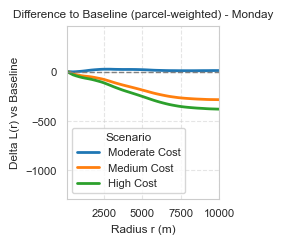

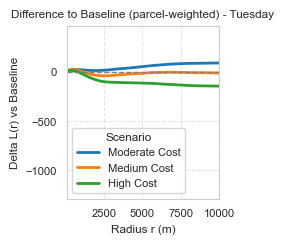

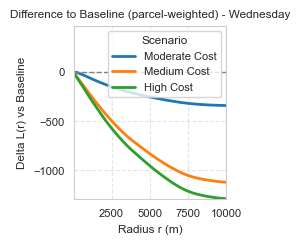

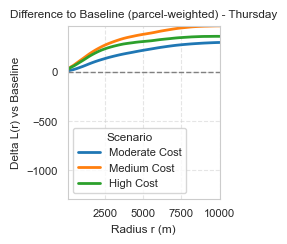

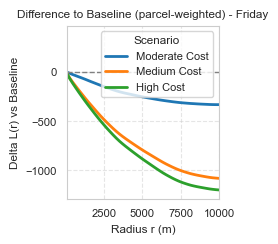

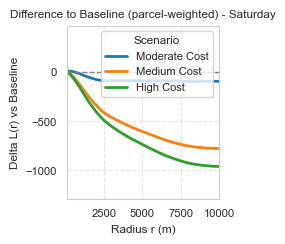

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

# ---------- your existing helpers (unchanged) ----------
# K_naive_hist_batch, weighted_quantile, weighted_iqr_band, carriers, scenarios, weekdays, ...
# Settings
R_MIN = 50.0
N_RADII = 50
R_MAX_FRACTION = 1
R_MAX_ABS = 10000.0
N_TEST = None
DELTA_MODE = "absolute"  # or "percent"

# ---------- 0) Build a GLOBAL r grid used for all days ----------
min_side_global = np.inf
for _, weekdict in scenarios:
    for day in weekdays:
        gdf_day = weekdict.get(day)
        if gdf_day is None or gdf_day.empty:
            continue
        minx, miny, maxx, maxy = gdf_day.total_bounds
        width = maxx - minx
        height = maxy - miny
        if width > 0 and height > 0:
            min_side_global = min(min_side_global, min(width, height))

if not np.isfinite(min_side_global):
    raise RuntimeError("No valid bounds across scenarios/days.")

R_MAX_GLOBAL = min(R_MAX_ABS, R_MAX_FRACTION * min_side_global)  # keep your cap logic
if R_MAX_GLOBAL <= R_MIN:
    raise RuntimeError("Global r_max too small for chosen settings.")
R_VALUES_GLOBAL = np.linspace(R_MIN, R_MAX_GLOBAL, N_RADII)

print(f"Global min side: {min_side_global:.1f} m")
print(f"Global r grid: {R_VALUES_GLOBAL[0]:.1f} m to {R_VALUES_GLOBAL[-1]:.1f} m ({N_RADII} steps)")

# ---------- 1) First pass: compute and cache per-day results + global delta range ----------
all_results = {}          # day -> {scenario -> L_avg}
all_results_car = {}      # day -> {scenario -> {"per_carrier":..., "weights":...}} (for band plot)
delta_y_min = np.inf
delta_y_max = -np.inf

def compute_L_for_carrier_naive(gdf_all, carrier_cols, r_values, area_fixed, n_sample=None, seed=42):
    cols_present = [c for c in carrier_cols if c in gdf_all.columns]
    if len(cols_present) != 2:
        return None, 0.0
    mask = gdf_all[cols_present].sum(axis=1) > 0
    gdf_c = gdf_all.loc[mask]
    if gdf_c.empty:
        return None, 0.0
    if n_sample is not None and len(gdf_c) > n_sample:
        gdf_c = gdf_c.sample(n=n_sample, random_state=seed).copy()
    points = np.array([(geom.x, geom.y) for geom in gdf_c.geometry.centroid])
    if len(points) < 2:
        return None, 0.0
    # use per-day fixed area but GLOBAL r grid
    minx, miny, maxx, maxy = gdf_all.total_bounds
    area_fixed = (maxx - minx) * (maxy - miny)
    K = K_naive_hist_batch(points, R_VALUES_GLOBAL, area_fixed)
    L = np.sqrt(K / np.pi) - R_VALUES_GLOBAL
    weight = float(gdf_c[cols_present].to_numpy().sum())
    return L, weight

for day in weekdays:
    # Per-day fixed window (only to get area; r will be global)
    # Use the union across scenarios for fair area; if you prefer union, compute as in your code
    have_any = False
    minx_all, miny_all, maxx_all, maxy_all = np.inf, np.inf, -np.inf, -np.inf
    for _, weekdict in scenarios:
        gdf_day = weekdict.get(day)
        if gdf_day is None or gdf_day.empty:
            continue
        minx, miny, maxx, maxy = gdf_day.total_bounds
        minx_all = min(minx_all, minx); miny_all = min(miny_all, miny)
        maxx_all = max(maxx_all, maxx); maxy_all = max(maxy_all, maxy)
        have_any = True
    if not have_any:
        continue
    area_fixed_day = (maxx_all - minx_all) * (maxy_all - miny_all)

    results_day = {}
    results_car_day = {}

    for scen_name, weekdict in scenarios:
        gdf_all = weekdict.get(day)
        if gdf_all is None or gdf_all.empty:
            continue
        if N_TEST is not None and len(gdf_all) > N_TEST:
            gdf_all = gdf_all.sample(n=N_TEST, random_state=42).copy()

        per_carrier_L, per_carrier_w, per_names = [], [], []
        per_carrier_map, per_weight_map = {}, {}
        for cname, cols in carriers.items():
            res = compute_L_for_carrier_naive(gdf_all, cols, R_VALUES_GLOBAL, area_fixed_day)
            if res is None:
                continue
            L_arr, w = res
            if L_arr is None or not np.isfinite(w) or w <= 0:
                continue
            per_carrier_L.append(L_arr); per_carrier_w.append(w); per_names.append(cname)
            per_carrier_map[cname] = L_arr; per_weight_map[cname] = w

        if len(per_carrier_L) == 0:
            continue

        L_stack = np.vstack(per_carrier_L)
        w_arr = np.array(per_carrier_w, dtype=float)
        L_avg = np.average(L_stack, axis=0, weights=w_arr / np.sum(w_arr)) if np.sum(w_arr) > 0 else np.nanmean(L_stack, axis=0)

        results_day[scen_name] = L_avg
        results_car_day[scen_name] = {"per_carrier": per_carrier_map, "weights": per_weight_map}

    if len(results_day) == 0:
        continue

    all_results[day] = results_day
    all_results_car[day] = results_car_day

    # Update global delta range using this day
    base_name = "Baseline" if "Baseline" in results_day else next(iter(results_day.keys()))
    L_base = results_day[base_name]
    for scen_name, L_avg in results_day.items():
        if scen_name == base_name:
            continue
        if DELTA_MODE == "percent":
            eps = 1e-9
            delta = 100.0 * (L_avg - L_base) / np.maximum(np.abs(L_base), eps)
        else:
            delta = L_avg - L_base
        delta_y_min = min(delta_y_min, float(np.nanmin(delta)))
        delta_y_max = max(delta_y_max, float(np.nanmax(delta)))

# Safety if nothing computed
if not all_results:
    raise RuntimeError("No results to plot.")

# ---------- 2) Plot per-day difference with identical axes ----------
for day, results_day in all_results.items():
    base_name = "Baseline" if "Baseline" in results_day else next(iter(results_day.keys()))
    L_base = results_day[base_name]

    # Lines only
    plt.figure(figsize=(2.5, 2.5))
    for scen_name, L_avg in results_day.items():
        if scen_name == base_name:
            continue
        if DELTA_MODE == "percent":
            eps = 1e-9
            delta = 100.0 * (L_avg - L_base) / np.maximum(np.abs(L_base), eps)
            ylab = "Percent difference vs Baseline (%)"
        else:
            delta = L_avg - L_base
            ylab = "Delta L(r) vs Baseline"
        plt.plot(R_VALUES_GLOBAL, delta, lw=2.0, label=scen_name)
    plt.axhline(0.0, linestyle="--", color="gray", linewidth=1.0)
    plt.xlim(R_MIN, R_VALUES_GLOBAL[-1])
    plt.ylim(delta_y_min, delta_y_max)
    plt.xlabel("Radius r (m)")
    plt.ylabel(ylab)
    plt.title(f"Difference to {base_name} (parcel-weighted) - {day}")
    plt.legend(title="Scenario")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # # With weighted IQR band across carriers
    # base_payload = all_results_car[day][base_name]
    # plt.figure(figsize=(6, 4))
    # for scen_name, scen_payload in all_results_car[day].items():
    #     if scen_name == base_name:
    #         continue
    #     # align carriers and compute per-carrier deltas
    #     common = sorted(set(base_payload["per_carrier"]).intersection(scen_payload["per_carrier"]))
    #     if not common:
    #         continue
    #     Lb = np.vstack([base_payload["per_carrier"][c] for c in common])
    #     Ls = np.vstack([scen_payload["per_carrier"][c] for c in common])
    #     wb = np.array([base_payload["weights"].get(c, 0.0) for c in common], float)
    #     ws = np.array([scen_payload["weights"].get(c, 0.0) for c in common], float)
    #     w_star = wb + ws
    #     if DELTA_MODE == "percent":
    #         eps = 1e-9
    #         Delta_stack = 100.0 * (Ls - Lb) / np.maximum(np.abs(Lb), eps)
    #         ylab = "Percent difference vs Baseline (%)"
    #     else:
    #         Delta_stack = Ls - Lb
    #         ylab = "Delta L(r) vs Baseline"
    #     # weighted mean and band
    #     delta_mean = np.average(Delta_stack, axis=0, weights=w_star / np.sum(w_star)) if np.sum(w_star) > 0 else np.nanmean(Delta_stack, axis=0)
    #     delta_lo, delta_hi = weighted_iqr_band(Delta_stack, w_star)
    #     band = plt.fill_between(R_VALUES_GLOBAL, delta_lo, delta_hi, alpha=0.18)
    #     color = band.get_facecolor()[0]
    #     plt.plot(R_VALUES_GLOBAL, delta_mean, lw=2.2, color=color, label=scen_name)

    # plt.axhline(0.0, linestyle="--", color="gray", linewidth=1.0)
    # plt.xlim(R_MIN, R_VALUES_GLOBAL[-1])
    # plt.ylim(delta_y_min, delta_y_max)
    # plt.xlabel("Radius r (m)")
    # plt.ylabel(ylab)
    # plt.title(f"Difference to {base_name} with weighted IQR band - {day}")
    # plt.legend(title="Scenario")
    # plt.grid(True, linestyle="--", alpha=0.5)
    # plt.tight_layout()
    # plt.show()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_13208\1803306997.py:89: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


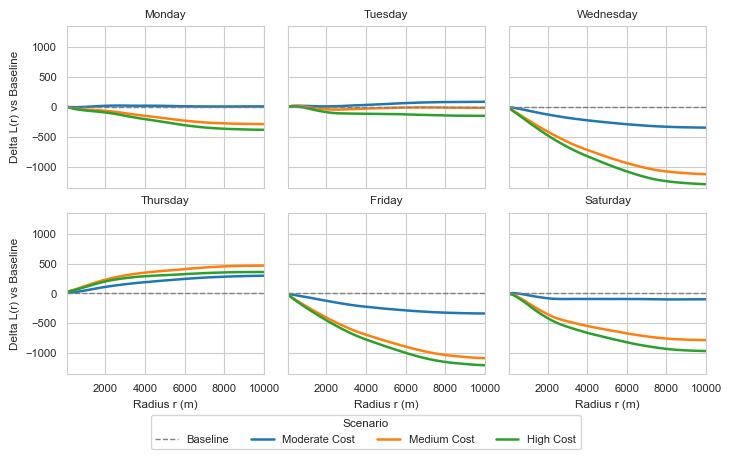

Saved: fig_weekday_deltas_3x2_fixedylim.pdf


In [106]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# figure layout
cols, rows = 3, 2
fig_w = 7.2   # two column width
panel_aspect = 0.85
fig_h = rows * (fig_w / cols) * panel_aspect

# fixed axes limits for all panels
Y_MIN, Y_MAX = -1350.0, 1350.0

plt.rcParams.update({
    "font.size": 8.5,
    "axes.labelsize": 8.5,
    "axes.titlesize": 8.5,
    "legend.fontsize": 8.0,
    "xtick.labelsize": 8.0,
    "ytick.labelsize": 8.0,
    "lines.linewidth": 1.8,
})

fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h),
                         sharex=True, sharey=True, constrained_layout=True)
axes_flat = axes.ravel()

# choose order of weekdays to plot
days_to_plot = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

# helper to get baseline name
def get_base_name(res_day):
    return "Baseline" if "Baseline" in res_day else next(iter(res_day.keys()))

# collect legend handles
legend_labels = []
legend_handles = []
baseline_handle = Line2D([0], [0], linestyle="--", color="gray", linewidth=1.0, label="Baseline")

for idx, day in enumerate(days_to_plot):
    ax = axes_flat[idx]
    if day not in all_results:
        ax.axis("off")
        continue

    res_day = all_results[day]
    base_name = get_base_name(res_day)
    L_base = res_day[base_name]

    # plot deltas for all scenarios except baseline
    for scen_name, L_avg in res_day.items():
        if scen_name == base_name:
            continue

        if DELTA_MODE == "percent":
            eps = 1e-9
            delta = 100.0 * (L_avg - L_base) / np.maximum(np.abs(L_base), eps)
            ylab = "Percent difference vs Baseline (%)"
        else:
            delta = L_avg - L_base
            ylab = "Delta L(r) vs Baseline"

        line, = ax.plot(R_VALUES_GLOBAL, delta, label=scen_name)
        # record legend entries once
        if scen_name not in legend_labels:
            legend_labels.append(scen_name)
            legend_handles.append(line)

    # zero line and fixed limits
    ax.axhline(0.0, linestyle="--", color="gray", linewidth=1.0)
    ax.set_xlim(R_MIN, R_VALUES_GLOBAL[-1])
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_title(day)

    # axis labels only on left column and bottom row
    if idx % cols == 0:
        ax.set_ylabel(ylab)
    if idx // cols == rows - 1:
        ax.set_xlabel("Radius r (m)")

# place figure level legend below with baseline entry
legend_handles = [baseline_handle] + legend_handles
fig.legend(handles=legend_handles,
           loc="lower center",
           ncol=min(len(legend_handles), 4),
           frameon=True,
           title="Scenario",
           bbox_to_anchor=(0.5, -0.1))
fig.subplots_adjust(bottom=0.16)

out_path = "fig_weekday_deltas_3x2_fixedylim.pdf"
# plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


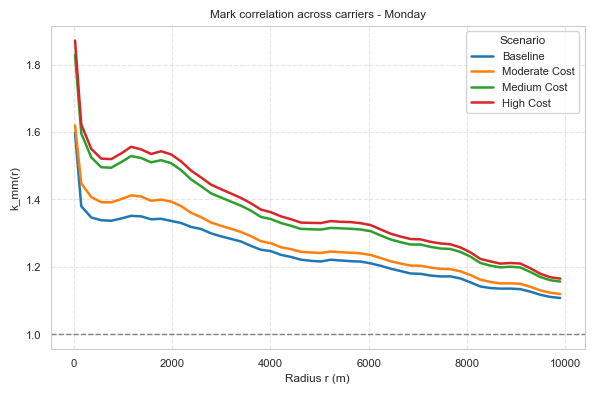

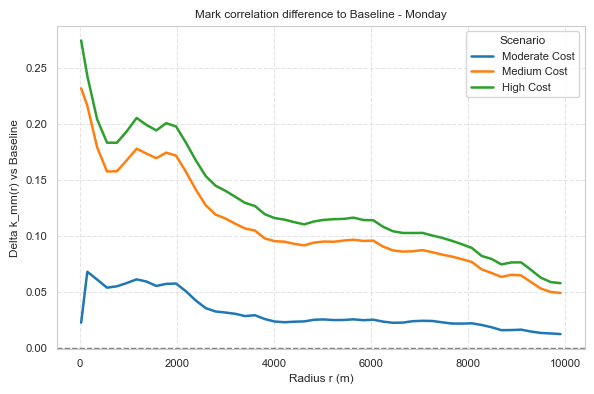

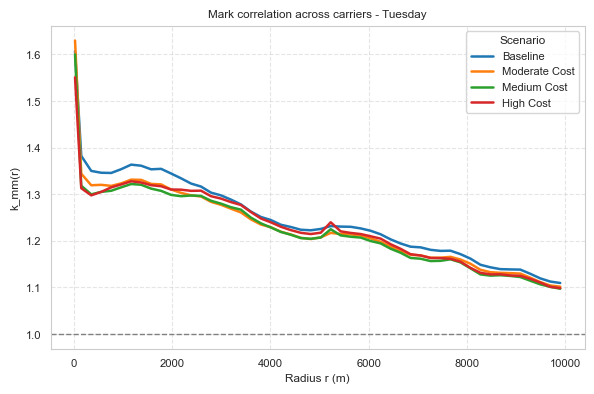

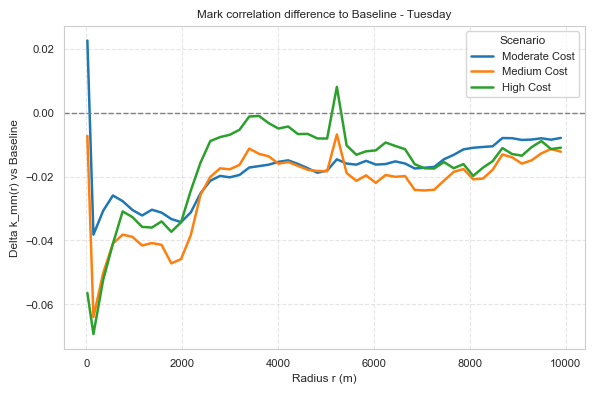

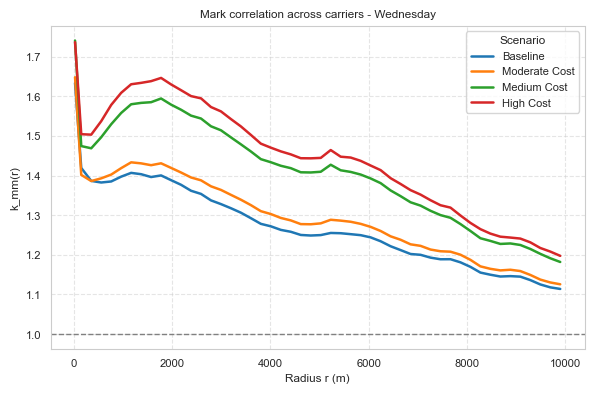

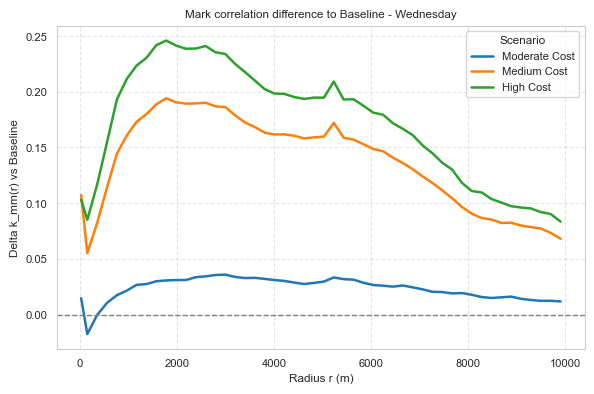

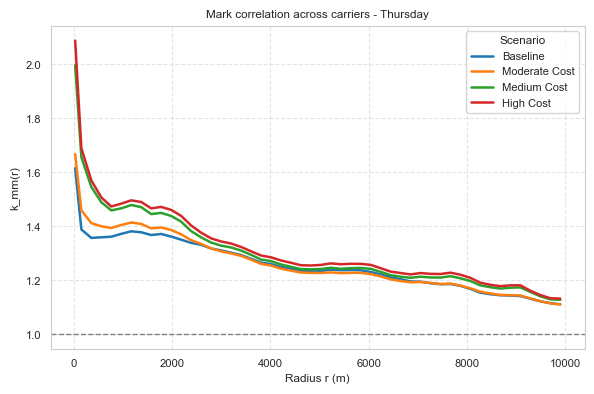

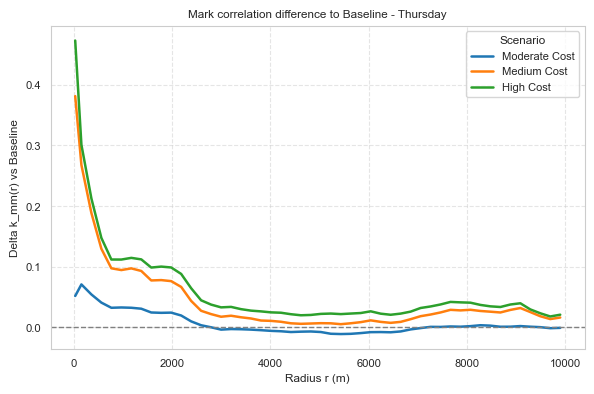

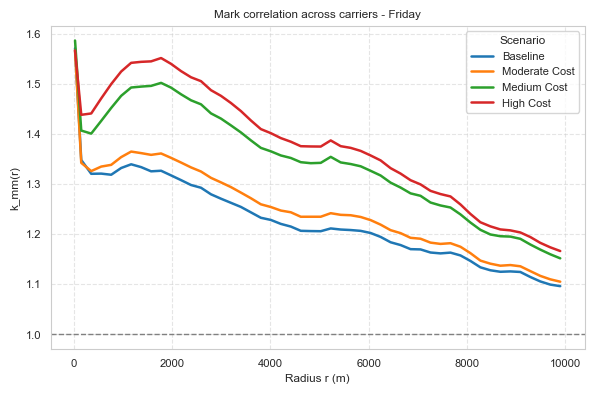

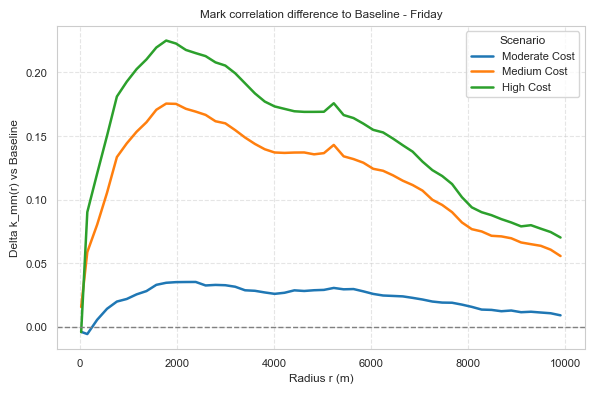

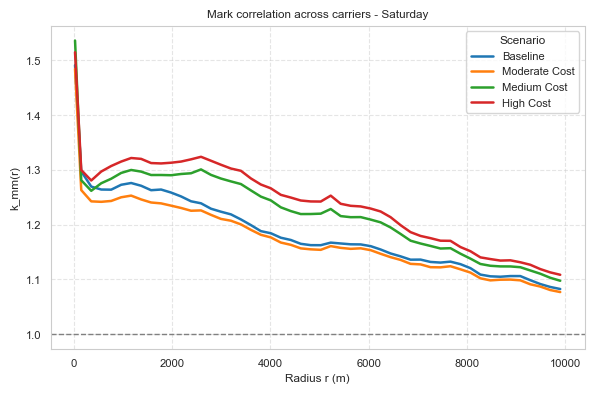

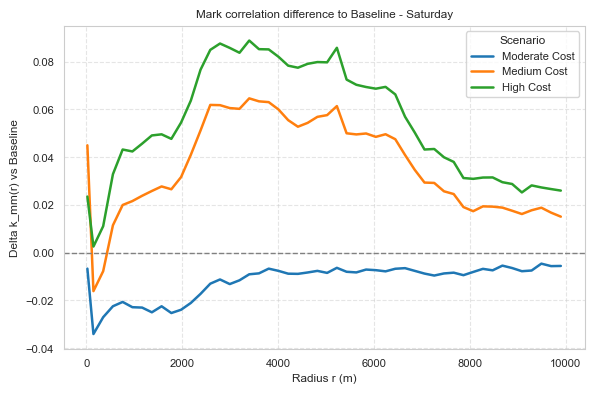

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

# ---------- Weighted pair histogram for mark correlation ----------
def mark_correlation_hist(points, weights, r_values, leaf_size=100, batch_size=2048):
    """
    Estimate k_mm(r) = E[w_i * w_j | r-bin] / (E[w])^2 using annular bins.
    points  : (n,2) float64 in meters
    weights : (n,) nonnegative weights per point (e.g. parcels in cell)
    r_values: (m,) ascending radii where you want k_mm at bin centers
              Assumes quasi-uniform spacing to define annular bins.
    Returns: (bin_centers, kmm) with length m-1 if using annuli between r[k]..r[k+1]
             or length m if you pass edges accordingly.
    """
    points = np.asarray(points, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)
    r_values = np.asarray(r_values, dtype=np.float64)

    n = len(points)
    if n < 2 or weights.sum() <= 0:
        # return empty arrays for graceful handling
        return np.array([]), np.array([])

    # Build annular bin edges from r_values.
    # If r_values are radii where you want the curve, use them as edges and derive centers.
    edges = np.array(r_values, dtype=np.float64)
    if edges[0] > 0.0:
        edges = np.concatenate(([0.0], edges))
    # centers between consecutive edges
    centers = 0.5 * (edges[1:] + edges[:-1])

    tree = BallTree(points, metric="euclidean", leaf_size=leaf_size)

    # Histograms for sum of pair weights and pair counts per annulus
    sum_wij = np.zeros(edges.size - 1, dtype=np.float64)
    cnt_pairs = np.zeros(edges.size - 1, dtype=np.float64)

    r_max = float(edges[-1])

    for start in range(0, n, batch_size):
        stop = min(start + batch_size, n)
        centers_batch = points[start:stop]
        wi_batch = weights[start:stop]

        idx_list, dist_list = tree.query_radius(
            centers_batch, r=r_max, return_distance=True, sort_results=True
        )
        for wi, idxs, dists in zip(wi_batch, idx_list, dist_list):
            if len(idxs) <= 1:
                continue
            # drop self
            idxs = idxs[1:]
            d = dists[1:]
            wj = weights[idxs]
            wij = wi * wj

            # annular histogram
            h_cnt, _ = np.histogram(d, bins=edges)
            h_wij, _ = np.histogram(d, bins=edges, weights=wij)

            cnt_pairs += h_cnt
            sum_wij += h_wij

    # Mean mark product per annulus
    with np.errstate(divide="ignore", invalid="ignore"):
        mean_wij = np.where(cnt_pairs > 0, sum_wij / cnt_pairs, np.nan)
    mu_w = float(weights.mean())
    denom = mu_w * mu_w if mu_w > 0 else np.nan

    kmm = mean_wij / denom
    return centers, kmm

# ---------- Convenience wrapper per carrier ----------
def compute_kmm_for_carrier(gdf_all, carrier_cols, r_edges, n_sample=None, seed=42):
    """
    r_edges: monotonically increasing array used as annular bin edges, e.g. np.linspace(100, 3000, 30)
    Returns (centers, kmm, carrier_volume) or (None, None, 0.0) if not enough data.
    """
    cols_present = [c for c in carrier_cols if c in gdf_all.columns]
    if len(cols_present) != 2:
        return None, None, 0.0

    mask = gdf_all[cols_present].sum(axis=1) > 0
    gdf_c = gdf_all.loc[mask]
    if gdf_c.empty:
        return None, None, 0.0

    if n_sample is not None and len(gdf_c) > n_sample:
        gdf_c = gdf_c.sample(n=n_sample, random_state=seed).copy()

    geoms = gdf_c["point_geom"].values if "point_geom" in gdf_c.columns else gdf_c.geometry.values
    points = np.array([(g.x, g.y) for g in geoms], dtype=float)
    weights = gdf_c[cols_present].sum(axis=1).to_numpy(dtype=float)

    if len(points) < 2 or np.all(weights <= 0):
        return None, None, 0.0

    centers, kmm = mark_correlation_hist(points, weights, r_edges)
    w_carrier = float(weights.sum())
    return centers, kmm, w_carrier

# ---------- Example usage inside your loop structure ----------
# Assume you already have:
#   scenarios, weekdays, carriers, R_VALUES_GLOBAL (as edges), DELTA_MODE, etc.

all_kmm = {}  # day -> {scenario -> (centers, kmm_mean)}
for day in weekdays:
    if day not in all_results:
        continue  # reuse your availability check

    # Use the same global r grid for annular bins
    r_edges = R_VALUES_GLOBAL  # must be edges; ensure it starts at 0 if desired

    kmm_day = {}
    for scen_name, weekdict in scenarios:
        gdf_all = weekdict.get(day)
        if gdf_all is None or gdf_all.empty:
            continue

        per_c = []
        per_w = []
        centers_ref = None

        for cname, cols in carriers.items():
            centers, kmm, w = compute_kmm_for_carrier(
                gdf_all, cols, r_edges=r_edges, n_sample=None, seed=123
            )
            if centers is None or kmm is None or not np.isfinite(w) or w <= 0:
                continue
            if centers_ref is None:
                centers_ref = centers
            per_c.append(kmm)
            per_w.append(w)

        if len(per_c) == 0:
            continue

        kmm_stack = np.vstack(per_c)
        w_arr = np.asarray(per_w, dtype=float)
        # parcel weighted mean across carriers
        kmm_mean = np.average(kmm_stack, axis=0, weights=w_arr / w_arr.sum()) if w_arr.sum() > 0 else np.nanmean(kmm_stack, axis=0)
        kmm_day[scen_name] = (centers_ref, kmm_mean)

    if kmm_day:
        all_kmm[day] = kmm_day



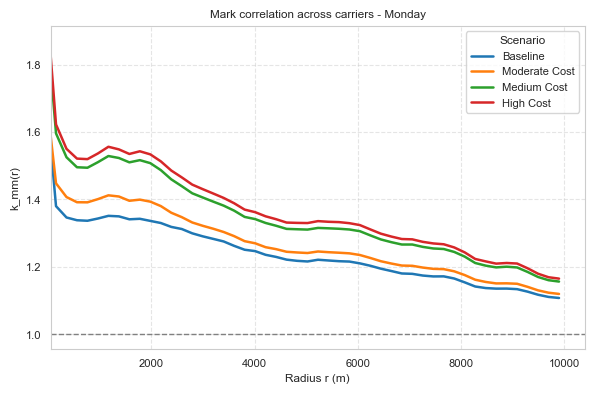

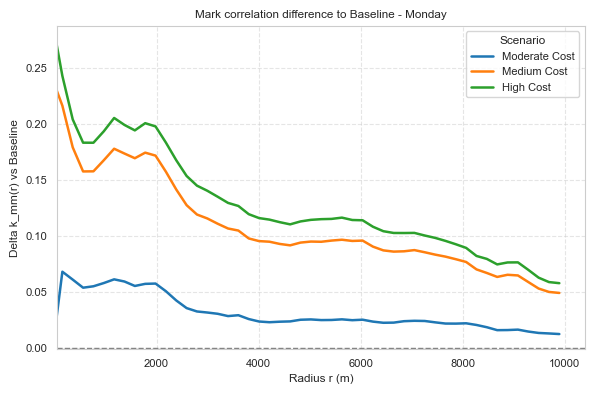

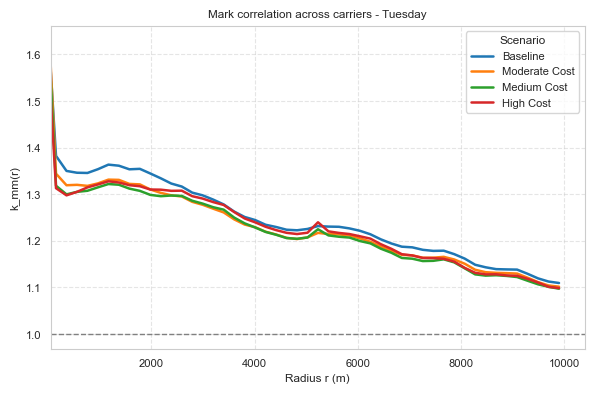

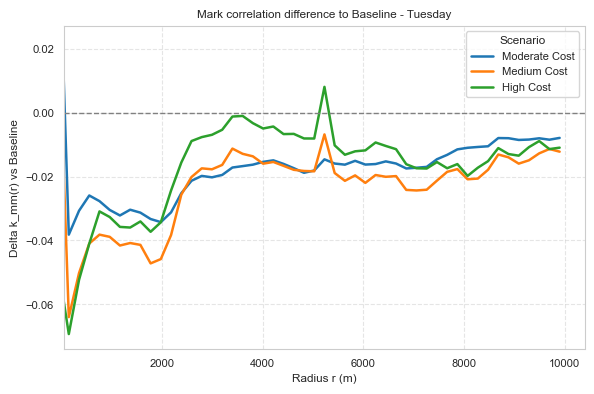

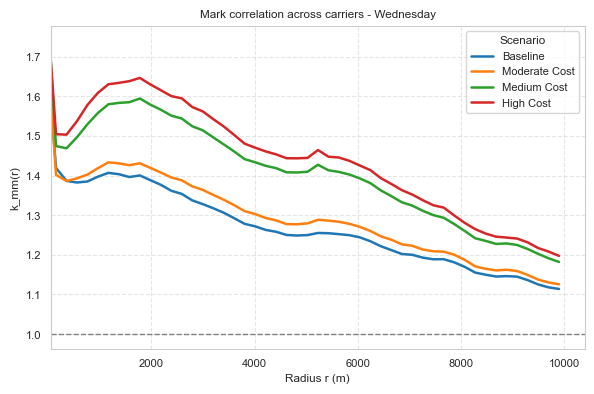

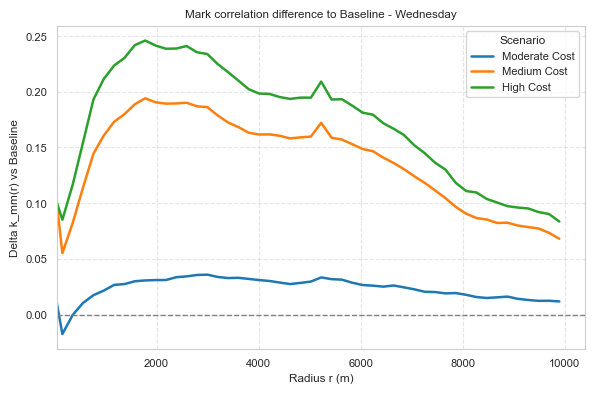

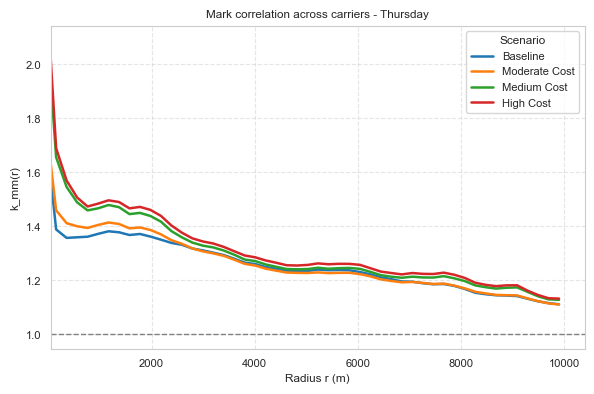

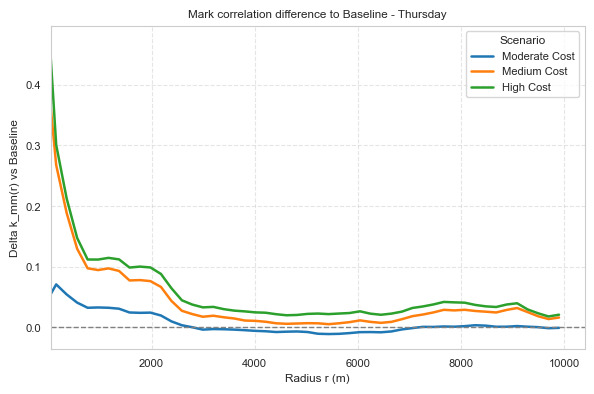

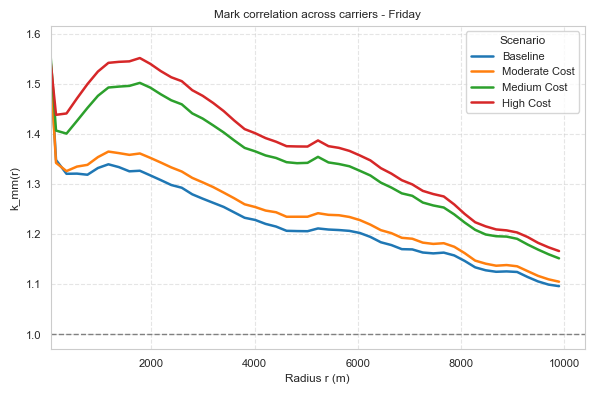

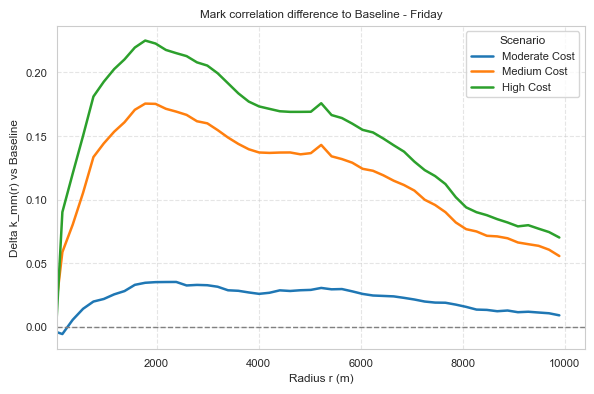

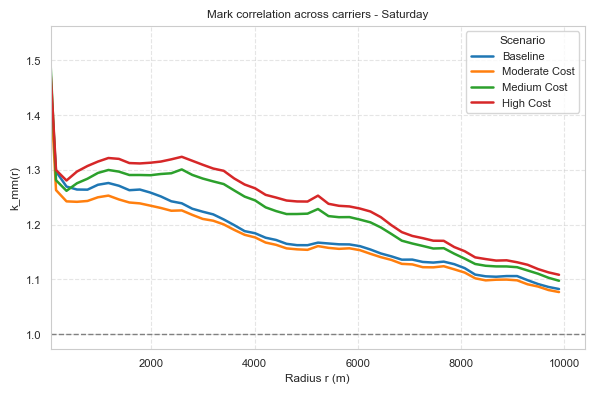

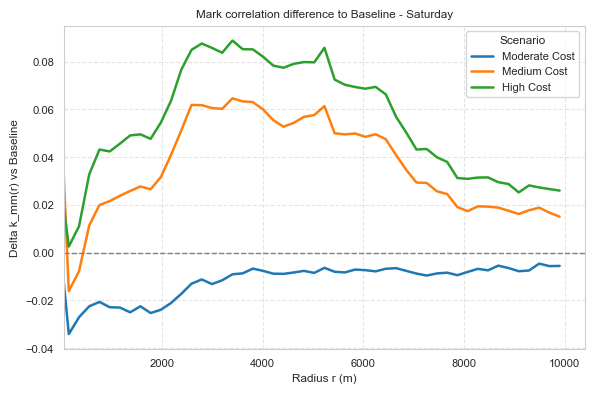

In [113]:
# ---------- Plot: k_mm absolute and difference to baseline ----------
for day, res in all_kmm.items():
    base_name = "Baseline" if "Baseline" in res else next(iter(res.keys()))
    centers_base, kmm_base = res[base_name]

    # Absolute k_mm
    plt.figure(figsize=(6, 4))
    for scen_name, (centers, kmm) in res.items():
        plt.plot(centers, kmm, label=scen_name)
    plt.axhline(1.0, linestyle="--", color="gray", linewidth=1.0)  # 1 is neutral
    plt.xlabel("Radius r (m)")
    plt.ylabel("k_mm(r)")
    plt.xlim(50, None)
    plt.title(f"Mark correlation across carriers - {day}")
    plt.legend(title="Scenario")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()    
    plt.show()

    # Difference vs baseline
    plt.figure(figsize=(6, 4))
    for scen_name, (centers, kmm) in res.items():
        if scen_name == base_name:
            continue
        if DELTA_MODE == "percent":
            eps = 1e-9
            delta = 100.0 * (kmm - kmm_base) / np.maximum(np.abs(kmm_base), eps)
            ylab = "Percent difference vs Baseline (%)"
        else:
            delta = kmm - kmm_base
            ylab = "Delta k_mm(r) vs Baseline"

        plt.plot(centers, delta, label=scen_name)

    plt.axhline(0.0, linestyle="--", color="gray", linewidth=1.0)
    plt.xlabel("Radius r (m)")
    plt.xlim(50, None)
    plt.ylabel(ylab)
    plt.title(f"Mark correlation difference to {base_name} - {day}")
    plt.legend(title="Scenario")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


## Adaptive k_mm-Binning + Deduplikation (neu)

Diese Zelle ergänzt die bestehende k_mm-Analyse um:

- adaptive Ringkanten (Annuli), die zur realen Distanzverteilung des Baseline-Tags passen (stabile Kurven, weniger Nahbereichs-Zacken),
- optionale Zusammenfassung ko-lokierter Punkte (z. B. 1 m Toleranz) zur Reduktion von 0–ε-Distanzen,
- identische r-Min/Max über Szenarien (Vergleichbarkeit), aber passende Bin-Aufteilung pro Tag,
- robuste Fallbacks, falls einzelne Variablen (z. B. `carriers`) fehlen.

Hinweis zur Rechenzeit: Die adaptiven Kanten werden pro Tag einmal aus einer Stichprobe von Nachbarschaftsdistanzen geschätzt (BallTree). Das kostet typischerweise Sekunden, nicht Minuten, und ist über Parameter steuerbar.

In [2]:
# ---------- your existing helpers (unchanged) ----------
# K_naive_hist_batch, weighted_quantile, weighted_iqr_band, carriers, scenarios, weekdays, ...
# Settings
R_MIN = 50.0
N_RADII = 50
R_MAX_FRACTION = 1
R_MAX_ABS = 10000.0
N_TEST = None
DELTA_MODE = "absolute"  # or "percent"

# ---------- 0) Build a GLOBAL r grid used for all days ----------
min_side_global = np.inf
for _, weekdict in scenarios:
    for day in weekdays:
        gdf_day = weekdict.get(day)
        if gdf_day is None or gdf_day.empty:
            continue
        minx, miny, maxx, maxy = gdf_day.total_bounds
        width = maxx - minx
        height = maxy - miny
        if width > 0 and height > 0:
            min_side_global = min(min_side_global, min(width, height))

if not np.isfinite(min_side_global):
    raise RuntimeError("No valid bounds across scenarios/days.")

R_MAX_GLOBAL = min(R_MAX_ABS, R_MAX_FRACTION * min_side_global)  # keep your cap logic
if R_MAX_GLOBAL <= R_MIN:
    raise RuntimeError("Global r_max too small for chosen settings.")
R_VALUES_GLOBAL = np.linspace(R_MIN, R_MAX_GLOBAL, N_RADII)

print(f"Global min side: {min_side_global:.1f} m")
print(f"Global r grid: {R_VALUES_GLOBAL[0]:.1f} m to {R_VALUES_GLOBAL[-1]:.1f} m ({N_RADII} steps)")

NameError: name 'np' is not defined

In [ ]:
# --- Adaptive k_mm mit optionaler Deduplikation, Plot und Progress ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
import warnings

# Optional: Fortschrittsbalken
try:
    from tqdm.auto import tqdm  # funktioniert in Jupyter/VS Code
except Exception:
    tqdm = None

class _DummyPbar:
    def __init__(self, total=0, desc=""):
        self.total = int(total) if total is not None else 0
        self.n = 0
        self.desc = desc
    def update(self, n=1):
        self.n += int(n)
        step = max(1, self.total // 5) if self.total > 0 else 1
        if self.n == 1 or self.n == self.total or (self.n % step) == 0:
            print(f"{self.desc}: {self.n}/{self.total}")
    def close(self):
        pass

def _make_pbar(total, desc):
    if tqdm is not None:
        try:
            return tqdm(total=total, desc=desc)
        except Exception:
            return _DummyPbar(total=total, desc=desc)
    return _DummyPbar(total=total, desc=desc)

def _collapse_duplicate_points(points, weights, tol=1.0):
    pts = np.asarray(points, dtype=float)
    w = np.asarray(weights, dtype=float)
    if pts.size == 0:
        return pts, w
    key = np.round(pts / tol).astype(np.int64)
    uniq, inv = np.unique(key, axis=0, return_inverse=True)
    sum_xy = np.zeros_like(uniq, dtype=float)
    sum_w = np.zeros(uniq.shape[0], dtype=float)
    cnt = np.zeros(uniq.shape[0], dtype=float)
    for i, k in enumerate(inv):
        sum_xy[k] += pts[i]
        sum_w[k] += w[i]
        cnt[k] += 1.0
    pts_out = sum_xy / np.maximum(cnt[:, None], 1.0)
    w_out = sum_w
    return pts_out, w_out

def _sample_pairwise_distances(points, weights, r_max, n_centers=1500, max_neighbors=1500, seed=42):
    rng = np.random.default_rng(seed)
    points = np.asarray(points, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)
    n = len(points)
    if n < 2:
        return np.array([]), np.array([])
    tree = BallTree(points, metric="euclidean", leaf_size=100)
    idx_centers = rng.choice(n, size=min(n_centers, n), replace=False)
    d_list, w_list = [], []
    for i in idx_centers:
        wi = float(weights[i])
        idxs, dists = tree.query_radius(points[i:i+1], r=r_max, return_distance=True, sort_results=True)
        idxs = idxs[0]; dists = dists[0]
        if len(idxs) <= 1:
            continue
        idxs = idxs[1:]; dists = dists[1:]
        if len(idxs) > max_neighbors:
            pick = rng.choice(len(idxs), size=max_neighbors, replace=False)
            idxs = idxs[pick]; dists = dists[pick]
        wj = weights[idxs]
        d_list.append(dists); w_list.append(wi * wj)
    if not d_list:
        return np.array([]), np.array([])
    d_sample = np.concatenate(d_list)
    w_pair = np.concatenate(w_list)
    return d_sample, w_pair

def _weighted_quantile(x, q, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    q = np.asarray(q, dtype=float)
    if x.size == 0:
        return np.array([])
    order = np.argsort(x)
    x_sorted = x[order]
    w_sorted = w[order]
    cdf = np.cumsum(w_sorted); cdf /= cdf[-1]
    return np.interp(q, cdf, x_sorted)

def _build_adaptive_edges(points, weights, r_min, r_max, target_pairs_per_bin=1500, min_bins=20, max_bins=120, min_bin_width=50.0, seed=42):
    d_sample, w_pair = _sample_pairwise_distances(points, weights, r_max, seed=seed)
    if d_sample.size < 100:
        step = max(min_bin_width, (r_max - r_min) / max(min_bins, 1))
        return np.arange(0.0, r_max + step, step)
    total_w = float(np.sum(w_pair))
    est_bins = int(np.clip(np.floor(total_w / max(target_pairs_per_bin, 1.0)), min_bins, max_bins))
    qs = np.linspace(0.0, 1.0, est_bins + 1)
    edges = _weighted_quantile(d_sample, qs, w_pair)
    edges = np.clip(edges, 0.0, r_max)
    if edges[0] > 0.0:
        edges[0] = 0.0
    fixed = [edges[0]]
    for e in edges[1:]:
        if e - fixed[-1] < min_bin_width:
            e = fixed[-1] + min_bin_width
        fixed.append(min(e, r_max))
    edges = np.array(fixed, dtype=float)
    edges = np.unique(edges)
    if edges.size < 3:
        step = max(min_bin_width, (r_max - r_min) / max(min_bins, 1))
        edges = np.arange(0.0, r_max + step, step)
    return edges

def _mark_correlation_hist(points, weights, r_edges, leaf_size=100, batch_size=2048, return_counts=False, pbar_batches=None, pbar_desc=None):
    pts = np.asarray(points, dtype=np.float64)
    w = np.asarray(weights, dtype=np.float64)
    if len(pts) < 2 or np.all(w <= 0):
        return (np.array([]), np.array([]), np.array([])) if return_counts else (np.array([]), np.array([]))
    tree = BallTree(pts, leaf_size=leaf_size)
    r_edges = np.asarray(r_edges, dtype=float)
    centers = 0.5 * (r_edges[:-1] + r_edges[1:])
    mean_w = np.mean(w); denom = (mean_w ** 2)
    sum_wij = np.zeros(len(centers), dtype=float)
    cnt_pairs = np.zeros(len(centers), dtype=np.int64)
    n_batches = int(np.ceil(len(pts) / float(batch_size)))
    local_pbar = None
    if pbar_batches is True:
        local_pbar = _make_pbar(n_batches, desc=pbar_desc or "k_mm batches")
    for start in range(0, len(pts), batch_size):
        stop = min(start + batch_size, len(pts))
        dists_list = tree.query_radius(pts[start:stop], r=r_edges[-1], return_distance=True, sort_results=True)
        for row_idx, (idxs, dists) in enumerate(zip(*dists_list)):
            if len(idxs) <= 1:
                continue
            wi = float(w[start + row_idx])
            idxs = idxs[1:]; dists = dists[1:]
            if idxs.size == 0:
                continue
            bin_idx = np.searchsorted(r_edges, dists, side="right") - 1
            valid = (bin_idx >= 0) & (bin_idx < len(centers))
            bin_idx = bin_idx[valid]
            wj = w[idxs[valid]]
            np.add.at(sum_wij, bin_idx, wi * wj)
            np.add.at(cnt_pairs, bin_idx, 1)
        if local_pbar is not None:
            local_pbar.update(1)
    if local_pbar is not None:
        local_pbar.close()
    with np.errstate(divide='ignore', invalid='ignore'):
        kmm = sum_wij / np.maximum(cnt_pairs, 1)
        kmm = kmm / np.maximum(denom, 1e-12)
    if return_counts:
        return centers, kmm, cnt_pairs
    return centers, kmm

def compute_adaptive_kmm(scens, days, carriers_dict=None, r_min=50.0, r_max=None, dedupe_tol=1.0, target_pairs_per_bin=1500, min_bins=20, max_bins=120, min_bin_width=50.0, seed=123, min_pairs_plot=50, r_min_plot=200.0, delta_mode="abs", show_progress=True, progress_level="carrier"):
    all_kmm = {}
    if r_max is None:
        try:
            r_max = float(R_VALUES_GLOBAL[-1])
        except Exception:
            r_max = 3000.0
    scen_dict = dict(scens)
    base_name = "Baseline" if "Baseline" in scen_dict else next(iter(scen_dict.keys()))
    for day in days:
        if day not in scen_dict.get(base_name, {}):
            continue
        gdf_base = scen_dict[base_name][day]
        if gdf_base is None or gdf_base.empty:
            continue
        geoms = gdf_base["point_geom"].values if "point_geom" in gdf_base.columns else gdf_base.geometry.values
        points_all = np.array([(g.x, g.y) for g in geoms], dtype=float)
        flow_cols = [c for c in gdf_base.columns if c.endswith("_b2b") or c.endswith("_b2c")]
        weights_all = gdf_base[flow_cols].sum(axis=1).to_numpy(dtype=float) if flow_cols else np.ones(len(points_all))
        points_all, weights_all = _collapse_duplicate_points(points_all, weights_all, tol=dedupe_tol)
        r_edges = _build_adaptive_edges(points_all, weights_all, r_min=r_min, r_max=r_max, target_pairs_per_bin=target_pairs_per_bin, min_bins=min_bins, max_bins=max_bins, min_bin_width=min_bin_width, seed=seed)
        print(f"{day}: adaptive edges gebaut → bins={len(r_edges)-1}, r∈[{r_edges[0]:.0f},{r_edges[-1]:.0f}] m")
        kmm_day = {}
        for scen_name, weekdict in scens:
            gdf_all = weekdict.get(day)
            if gdf_all is None or gdf_all.empty:
                continue
            centers_ref = None
            per_c, per_w = [], []
            # Carrier-Liste bestimmen
            cdict = carriers_dict
            if cdict is None:
                cdict = {}
                for c in ["amazon","dhl","dpd","fedex","gls","hermes","ups"]:
                    b2b = f"{c}_b2b"; b2c = f"{c}_b2c"
                    cols = [col for col in (b2b, b2c) if col in gdf_all.columns]
                    if cols:
                        cdict[c] = cols
            # Progress pro Szenario
            pbar = _make_pbar(len(cdict), desc=f"{day} • {scen_name}") if show_progress and len(cdict) > 0 else None
            for cname, cols in cdict.items():
                geoms = gdf_all["point_geom"].values if "point_geom" in gdf_all.columns else gdf_all.geometry.values
                pts = np.array([(g.x, g.y) for g in geoms], dtype=float)
                wts = gdf_all[[c for c in cols if c in gdf_all.columns]].sum(axis=1).to_numpy(dtype=float)
                if pts.size == 0 or np.all(wts <= 0):
                    if pbar is not None: pbar.update(1)
                    continue
                pts, wts = _collapse_duplicate_points(pts, wts, tol=dedupe_tol)
                use_batch_bar = show_progress and (progress_level == "batch")
                centers, kmm, cnt = _mark_correlation_hist(pts, wts, r_edges, return_counts=True, pbar_batches=use_batch_bar, pbar_desc=f"{day} • {scen_name} • {cname}")
                if centers.size == 0:
                    if pbar is not None: pbar.update(1)
                    continue
                mask = (centers >= r_min_plot) & (cnt >= min_pairs_plot)
                if not np.any(mask):
                    if pbar is not None: pbar.update(1)
                    continue
                centers = centers[mask]
                kmm = kmm[mask]
                if centers_ref is None:
                    centers_ref = centers
                per_c.append(kmm)
                per_w.append(float(wts.sum()))
                if pbar is not None: pbar.update(1)
            if pbar is not None:
                pbar.close()
            if per_c:
                kmm_stack = np.vstack(per_c)
                w_arr = np.asarray(per_w, dtype=float)
                kmm_mean = np.average(kmm_stack, axis=0, weights=w_arr / np.maximum(w_arr.sum(), 1e-9))
                kmm_day[scen_name] = (centers_ref, kmm_mean)
        if kmm_day:
            all_kmm[day] = kmm_day
    if not all_kmm:
        warnings.warn("Adaptive k_mm: keine Ergebnisse berechnet (prüfe Inputs).")
    else:
        for day, res in all_kmm.items():
            base_name_plot = "Baseline" if "Baseline" in res else next(iter(res.keys()))
            centers_base, kmm_base = res[base_name_plot]
            plt.figure(figsize=(6, 4))
            for scen_name, (centers, kmm) in res.items():
                plt.plot(centers, kmm, label=scen_name)
            plt.axhline(1.0, ls="--", c="gray", lw=1)
            plt.xlabel("Radius r (m)"); plt.ylabel("k_mm(r)"); plt.title(f"k_mm (adaptiv) - {day}")
            plt.grid(True, ls="--", alpha=0.5); plt.legend(); plt.tight_layout(); plt.show()
            plt.figure(figsize=(6, 4))
            for scen_name, (centers, kmm) in res.items():
                if scen_name == base_name_plot:
                    continue
                if delta_mode == "percent":
                    delta = 100.0 * (kmm - kmm_base) / np.maximum(np.abs(kmm_base), 1e-9)
                    ylab = "Delta vs Baseline (%)"
                else:
                    delta = kmm - kmm_base
                    ylab = "Delta vs Baseline"
                plt.plot(centers, delta, label=scen_name)
            plt.axhline(0.0, ls="--", c="gray", lw=1)
            plt.xlabel("Radius r (m)"); plt.ylabel(ylab); plt.title(f"k_mm Δ (adaptiv) - {day}")
            plt.grid(True, ls="--", alpha=0.5); plt.legend(); plt.tight_layout(); plt.show()
    return all_kmm

# ---- Ausführung mit aktuellen Notebook-Variablen ----
try:
    _ = compute_adaptive_kmm(
        scens=scenarios,
        days=weekdays,
        carriers_dict=carriers if 'carriers' in globals() else None,
        r_min=50.0, r_max=None,
        dedupe_tol=1.0,
        target_pairs_per_bin=1500,
        min_bins=20, max_bins=120,
        min_bin_width=50.0,
        seed=123,
        min_pairs_plot=50,
        r_min_plot=200.0,
        delta_mode="abs",
        show_progress=True,           # Fortschrittsbalken aktivieren
        progress_level="carrier",    # "carrier" (moderate Updates) oder "batch" (feiner)
    )
except Exception as e:
    warnings.warn(f"Adaptive k_mm konnte nicht ausgeführt werden: {e}")

ModuleNotFoundError: No module named 'numpy'